# Understanding the Difficulty of Training Deep Feedforward Neural Networks

**Authors:** Xavier Glorot, Yoshua Bengio (DIRO, Université de Montréal)
**Venue:** AISTATS 2010, JMLR W&CP Volume 9

---

## Abstract

Before 2006, deep multilayer neural networks trained with standard gradient descent from random initialization performed poorly, while newer approaches based on unsupervised pre-training or layer-wise schemes succeeded. This paper investigates why standard training fails, rather than why the new methods succeed. By monitoring activations and gradients across layers and training iterations, the authors show that the logistic sigmoid drives the top hidden layer into saturation, that saturated units can slowly escape (explaining training plateaus), and that less-saturating non-linearities such as softsign help. A variance analysis of forward activations and back-propagated gradients motivates a new **normalized initialization** that keeps layer-to-layer Jacobian singular values near 1, yielding substantially faster convergence and lower error.

---

## Problems

1. **Poor trainability of deep supervised networks:** Standard random initialization combined with gradient descent yields slow convergence and poor solutions in deep feedforward networks.
2. **Activation saturation:** The sigmoid, whose mean output is non-zero, pushes the top hidden layer into saturation at 0, blocking gradient flow to lower layers.
3. **Sequential saturation in tanh networks:** With the standard initialization, tanh layers saturate one after another, starting from the first layer.
4. **Unbalanced gradient variance across layers:** Back-propagated gradient variance shrinks toward the input layer at initialization, because each layer multiplies the signal by a factor below 1.
5. **Cost function plateaus:** The quadratic cost produces more severe plateaus in the loss surface than the cross-entropy cost.

---

## Proposed Solutions

| Problem | Proposed Remedy |
|---|---|
| Sigmoid top-layer saturation | Use activations symmetric around 0 (tanh, softsign) |
| Hard, exponential saturation | Softsign, which approaches its asymptotes polynomially |
| Loss surface plateaus | Conditional log-likelihood (cross-entropy) with softmax output |
| Vanishing or exploding signal variance | **Normalized initialization** (now known as Xavier/Glorot initialization) |

### Activation Functions Compared

$$\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}, \qquad \tanh(x), \qquad \text{softsign}(x) = \frac{x}{1 + |x|}$$

### Standard Initialization (Baseline)

$$W_{ij} \sim U\left[-\frac{1}{\sqrt{n}}, \frac{1}{\sqrt{n}}\right] \quad \Rightarrow \quad n \, \mathrm{Var}[W] = \frac{1}{3}$$

### Normalized Initialization (Proposed)

$$W \sim U\left[-\frac{\sqrt{6}}{\sqrt{n_j + n_{j+1}}}, \frac{\sqrt{6}}{\sqrt{n_j + n_{j+1}}}\right]$$

---

## Purpose

- Explain why standard back-propagation from random initialization fails in deep networks.
- Clarify, by contrast, why pre-training and new training schemes succeed.
- Provide diagnostic tools (monitoring activations, gradients, and Jacobians) and principled design choices to close the gap between purely supervised deep networks and pre-trained ones.

---

## Methodology

### Theoretical Analysis

Under a linear regime at initialization ($$f'(s) \approx 1$$), with independent weights and equal input feature variances, for layer $$i$$ with width $$n_i$$:

$$\mathrm{Var}[z^i] = \mathrm{Var}[x] \prod_{i'=0}^{i-1} n_{i'} \, \mathrm{Var}[W^{i'}]$$

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^i}\right] = \mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^d}\right] \prod_{i'=i}^{d} n_{i'+1} \, \mathrm{Var}[W^{i'}]$$

Preserving variance in both directions requires:

$$\text{Forward: } n_i \, \mathrm{Var}[W^i] = 1, \qquad \text{Backward: } n_{i+1} \, \mathrm{Var}[W^i] = 1$$

The compromise between the two constraints is:

$$\mathrm{Var}[W^i] = \frac{2}{n_i + n_{i+1}}$$

A uniform distribution $$U[-a, a]$$ has variance $$a^2/3$$, which gives the normalized initialization bound $$a = \sqrt{6}/\sqrt{n_i + n_{i+1}}$$.

With equal layer widths, weight-gradient variance is identical across layers, while back-propagated gradient variance can still vanish or explode with depth:

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial w^i}\right] = \left[n \, \mathrm{Var}[W]\right]^d \mathrm{Var}[x] \, \mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^d}\right]$$

### Diagnostic: Layer Jacobian

$$J^i = \frac{\partial z^{i+1}}{\partial z^i}$$

The average singular value of $$J^i$$ measures the ratio of activation variance between consecutive layers. Values near 1 indicate healthy signal propagation.

### Experimental Setup

| Component | Configuration |
|---|---|
| Architecture | Feedforward networks, 1 to 5 hidden layers, 1000 units each |
| Output layer | Softmax logistic regression |
| Loss | Negative log-likelihood, $$-\log P(y \mid x)$$ |
| Optimizer | Stochastic back-propagation, mini-batches of size 10 |
| Hyperparameters | Learning rate and depth tuned per model on validation error |
| Biases | Initialized to 0 |
| Monitoring | Activations and gradients on a fixed set of 300 test examples |

### Datasets

| Dataset | Description | Train / Valid / Test |
|---|---|---|
| Shapeset-3×2 | Synthetic 32×32 images of 1 or 2 shapes (triangle, parallelogram, ellipse), 9 classes; infinite online setting | Sampled on demand |
| MNIST | 28×28 grayscale digits, 10 classes | 50k / 10k / 10k |
| CIFAR-10 | 32×32 color images, 10 classes (3072 inputs) | 40k / 10k / 10k |
| Small-ImageNet | 37×37 grayscale images, 10 WordNet classes | 90k / 10k / 10k |

---

## Results

### Activation Dynamics

- **Sigmoid:** The top hidden layer saturates at 0 almost immediately, while lower layers hold mean activations above 0.5. A four-layer network escapes saturation slowly (around epoch 100). A five-layer network never escapes.
- **Tanh (standard init):** Saturation occurs sequentially, beginning with layer 1 and propagating upward. The cause remains unexplained.
- **Softsign:** All layers saturate less and move together. Activations concentrate near the "knees" (around ±0.6 to ±0.8), where units are non-linear yet still pass gradients.

### Gradient Propagation

| Measure | Standard Init | Normalized Init |
|---|---|---|
| Average Jacobian singular value | about 0.5 | about 0.8 |
| Back-propagated gradient variance at init | Decreases toward input layer | Roughly constant across layers |
| Weight-gradient variance during training | Diverges across layers | Stays consistent across layers |

Weight-gradient variance stays roughly constant across layers at initialization even when back-propagated gradients shrink, consistent with the theoretical analysis.

### Test Error (%) for 5-Hidden-Layer Networks

"N" denotes normalized initialization.

| Model | Shapeset | MNIST | CIFAR-10 | ImageNet |
|---|---|---|---|---|
| Softsign | 16.27 | 1.64 | 55.78 | 69.14 |
| Softsign N | 16.06 | 1.72 | 53.80 | 68.13 |
| Tanh | 27.15 | 1.76 | 55.90 | 70.58 |
| **Tanh N** | **15.60** | **1.64** | **52.92** | **68.57** |
| Sigmoid | 82.61 | 2.21 | 57.28 | 70.66 |

### Additional Findings

- **Cost function:** Cross-entropy shows markedly fewer plateaus than quadratic cost on a two-layer tanh network.
- **Baseline:** On 100k Shapeset examples, an RBF SVM reached 59.47% error, compared with 50.47% for a depth-5 tanh network with normalized initialization.
- **Second-order methods:** Per-parameter learning rates (Hessian diagonal, gradient variance estimate) improve standard initialization but do not match normalized initialization. Combining them with normalized initialization gives further gains.
- **Robustness:** The gains persist when layer widths increase or decrease with depth.
- **Pre-training:** Normalized initialization closes a substantial part of the gap to unsupervised pre-training with denoising autoencoders.

---

## Conclusions

1. Monitoring activations and gradients across layers and training time is a powerful diagnostic for deep network training.
2. Sigmoid activations should be avoided with small random initialization. Their non-zero mean causes top-layer saturation and poor learning dynamics.
3. Softsign is more robust to initialization than tanh, likely because of its gentler non-linearity.
4. Keeping layer-to-layer Jacobians near 1 preserves both forward activation variance and backward gradient variance. The normalized initialization achieves this and eliminates much of the gap between purely supervised and pre-trained deep networks.
5. Several observations, including sequential tanh saturation, remain unexplained and call for further study of training dynamics.

### Significance

The paper established variance-preserving initialization as a foundational principle of deep learning. The Glorot (Xavier) initialization became a default in major frameworks and directly motivated later work such as He initialization for ReLU networks. It also reframed deep network training difficulty as a signal-propagation problem addressable by architecture and initialization design rather than requiring unsupervised pre-training.

# Mathematical and Statistical Content of Glorot & Bengio (2010)

**Paper:** *Understanding the Difficulty of Training Deep Feedforward Neural Networks*

---

## 1. Notation

| Symbol | Meaning |
|---|---|
| $x$ | Network input vector |
| $z^i$ | Activation (output) vector of layer $i$, with $z^0 = x$ |
| $s^i$ | Pre-activation vector at layer $i$ (the argument fed to the non-linearity) |
| $W^i, b^i$ | Weight matrix and bias vector of layer $i$ |
| $n_i$ | Number of units in layer $i$ |
| $d$ | Number of layers |
| $f$ | Activation function |
| $\theta$ | All trainable parameters |
| $\epsilon$ | Learning rate |

---

## 2. Activation Functions

$$\text{sigmoid}(x) = \frac{1}{1+e^{-x}}, \qquad \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}, \qquad \text{softsign}(x) = \frac{x}{1+\lvert x \rvert}$$

| Function | Range | Value at 0 | Slope at 0 | How it approaches its limits |
|---|---|---|---|---|
| Sigmoid | $(0, 1)$ | $0.5$ | $0.25$ | Exponentially fast |
| Tanh | $(-1, 1)$ | $0$ | $1$ | Exponentially fast |
| Softsign | $(-1, 1)$ | $0$ | $1$ | Polynomially slow |

**Role in the paper**

- **Saturation.** A unit is "saturated" when its output sits near an asymptote. There the derivative $f'(s)$ is nearly zero, so gradients cannot pass through it.
- **Why the sigmoid fails.** The sigmoid reaches an output of 0 only when $s \to -\infty$, which is a saturated region. Tanh and softsign output 0 at $s = 0$, where the slope is largest. When training pushes the top layer's outputs toward 0, symmetric functions stay in their best regime while the sigmoid dies.
- **Why softsign is gentler.** Its derivative decays like $1/x^2$, while tanh's derivative decays like $e^{-2\lvert x \rvert}$. Softsign units therefore keep some gradient far longer before saturating.

$$\text{softsign}'(x) = \frac{1}{(1+\lvert x \rvert)^2}, \qquad \tanh'(x) = 1 - \tanh^2(x)$$

---

## 3. Optimization and Cost Functions

### 3.1 Stochastic Gradient Descent

$$g = \frac{1}{10}\sum_{k=1}^{10} \frac{\partial\left(-\log P(y_k \mid x_k)\right)}{\partial \theta}, \qquad \theta \leftarrow \theta - \epsilon\, g$$

The gradient is averaged over a mini-batch of 10 examples, and the parameters step against it. The learning rate $\epsilon$ is chosen by validation error after 5 million updates.

### 3.2 Softmax Output and Negative Log-Likelihood

$$P(y \mid x) = \text{softmax}(b + Wh)_y = \frac{e^{(b+Wh)_y}}{\sum_c e^{(b+Wh)_c}}$$

$$\text{Cost} = -\log P(y \mid x)$$

The softmax turns raw scores into class probabilities. The cost penalizes the model when it assigns low probability to the correct class. This is the cross-entropy loss.

The paper's saturation argument relies on this formula. Early in training, the hidden features $h$ carry little useful information, so the easiest way for the network to reduce the cost is to rely on the biases $b$ and shrink $Wh$ toward zero. Shrinking $h$ achieves this, and for the sigmoid that means saturation.

### 3.3 Quadratic Cost (Comparison)

$$\text{Cost} = \lVert y - \hat{y} \rVert^2$$

Figure 5 plots both costs as surfaces over two weights. The quadratic cost has large flat regions (plateaus) where the gradient is near zero. Cross-entropy is steeper there, which is why it trains better for classification.

---

## 4. The Uniform Distribution and Standard Initialization

For $W \sim U[-a, a]$:

$$\mathbb{E}[W] = 0, \qquad \mathrm{Var}[W] = \frac{a^2}{3}$$

The standard heuristic (Eq. 1) uses $a = 1/\sqrt{n}$:

$$W_{ij} \sim U\left[-\frac{1}{\sqrt{n}}, \frac{1}{\sqrt{n}}\right] \quad \Rightarrow \quad \mathrm{Var}[W] = \frac{1}{3n} \quad \Rightarrow \quad n\,\mathrm{Var}[W] = \frac{1}{3}$$

The quantity $n\,\mathrm{Var}[W]$ is the factor by which each layer scales signal variance. Under the standard scheme, each layer multiplies variance by $1/3$, so the signal shrinks geometrically with depth.

---

## 5. Forward and Backward Propagation

### 5.1 Forward Pass

$$s^i = z^i W^i + b^i, \qquad z^{i+1} = f(s^i)$$

### 5.2 Backward Pass (Chain Rule)

**Eq. 2**

$$\frac{\partial \text{Cost}}{\partial s^i_k} = f'(s^i_k)\, W^{i+1}_{k,\bullet}\, \frac{\partial \text{Cost}}{\partial s^{i+1}}$$

**Eq. 3**

$$\frac{\partial \text{Cost}}{\partial w^i_{l,k}} = z^i_l \, \frac{\partial \text{Cost}}{\partial s^i_k}$$

- **Eq. 2:** The error signal at a unit equals its local slope times a weighted sum of error signals from the layer above. Since $s^{i+1} = f(s^i)\,W^{i+1} + b^{i+1}$, the weights connecting $s^i$ to $s^{i+1}$ are $W^{i+1}$.
- **Eq. 3:** A weight's gradient equals the input it receives times the error at its output unit.

---

## 6. Variance Propagation Analysis

This is the mathematical core of the paper.

### 6.1 Assumptions

1. **Linear regime:** $f'(s^i_k) \approx 1$ (Eq. 4). Valid near zero for tanh and softsign, since their slope at 0 is 1. It does not hold for the sigmoid.
2. **Independence:** Weights are independent of each other and of the inputs.
3. **Zero mean:** Weights have mean zero.
4. **Equal input variances:** Every input feature has variance $\mathrm{Var}[x]$.

### 6.2 The Key Statistical Fact

For independent, zero-mean random variables $W$ and $z$:

$$\mathrm{Var}[Wz] = \mathrm{Var}[W]\,\mathrm{Var}[z]$$

The variance of a sum of $n$ independent terms is the sum of their variances. Each unit in layer $i+1$ sums $n_i$ such products, so:

$$\mathrm{Var}[z^{i+1}] = n_i\,\mathrm{Var}[W^i]\,\mathrm{Var}[z^i]$$

### 6.3 Forward Variance

**Eq. 5**

$$\mathrm{Var}[z^i] = \mathrm{Var}[x] \prod_{i'=0}^{i-1} n_{i'}\,\mathrm{Var}[W^{i'}]$$

Activation variance at layer $i$ equals input variance times the product of every earlier layer's scaling factor.

### 6.4 Backward Variance

The same argument applied to Eq. 2 running downward, where each unit sums over the $n_{i'+1}$ units above it:

**Eq. 6**

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^i}\right] = \mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^d}\right] \prod_{i'=i}^{d} n_{i'+1}\,\mathrm{Var}[W^{i'}]$$

The gradient reaching layer $i$ is the top-layer gradient times the scaling factors of every layer above it.

### 6.5 Weight-Gradient Variance

Combining Eq. 3 with Eq. 5 and Eq. 6, since the weight gradient is the product of a forward activation and a backward error:

**Eq. 7**

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial w^i}\right] = \prod_{i'=0}^{i-1} n_{i'}\mathrm{Var}[W^{i'}] \prod_{i'=i}^{d-1} n_{i'+1}\mathrm{Var}[W^{i'}] \times \mathrm{Var}[x]\,\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^d}\right]$$

### 6.6 The Core Insight

Both Eq. 5 and Eq. 6 are **products** of per-layer factors:

- If each factor is below 1, the signal **vanishes** exponentially with depth.
- If each factor is above 1, the signal **explodes** exponentially with depth.
- Only a factor of exactly 1 keeps the signal **stable**.

---

## 7. Deriving the Normalized Initialization

### 7.1 Two Design Goals

**Eq. 8 (forward)**

$$\mathrm{Var}[z^i] = \mathrm{Var}[z^{i'}] \quad \forall\, (i, i')$$

**Eq. 9 (backward)**

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^i}\right] = \mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^{i'}}\right] \quad \forall\, (i, i')$$

### 7.2 Conditions That Achieve Them

Setting each factor in the products to 1:

**Eq. 10 (fan-in condition)**

$$n_i\,\mathrm{Var}[W^i] = 1$$

**Eq. 11 (fan-out condition)**

$$n_{i+1}\,\mathrm{Var}[W^i] = 1$$

Eq. 10 scales by **fan-in** (inputs to a unit). Eq. 11 scales by **fan-out** (outputs from a unit). Both can hold only when $n_i = n_{i+1}$.

### 7.3 The Compromise

**Eq. 12**

$$\mathrm{Var}[W^i] = \frac{2}{n_i + n_{i+1}}$$

This equals $1/n_{\text{avg}}$, where $n_{\text{avg}}$ is the arithmetic mean of fan-in and fan-out. Equivalently, it is the harmonic mean of the two ideal variances $1/n_i$ and $1/n_{i+1}$. When widths are equal, it satisfies both conditions exactly.

### 7.4 Converting to a Uniform Distribution

Setting $a^2/3 = 2/(n_j + n_{j+1})$ and solving for $a$:

$$a^2 = \frac{6}{n_j + n_{j+1}} \quad \Rightarrow \quad a = \frac{\sqrt{6}}{\sqrt{n_j + n_{j+1}}}$$

**Eq. 16 (normalized initialization)**

$$W \sim U\left[-\frac{\sqrt{6}}{\sqrt{n_j+n_{j+1}}}, \frac{\sqrt{6}}{\sqrt{n_j+n_{j+1}}}\right]$$

The $\sqrt{6}$ is simply $\sqrt{3 \times 2}$: the 3 undoes the uniform distribution's variance factor, and the 2 comes from averaging fan-in and fan-out.

### 7.5 Comparison

| Scheme | $\mathrm{Var}[W]$ (equal widths) | Per-layer factor $n\,\mathrm{Var}[W]$ | Signal after 5 layers |
|---|---|---|---|
| Standard | $1/(3n)$ | $1/3$ | $(1/3)^5 \approx 0.004$ |
| Normalized | $1/n$ | $1$ | $1$ |

---

## 8. Equal-Width Special Case

With all layers of width $n$ and identical weight variance:

**Eq. 13**

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^i}\right] = \left[n\,\mathrm{Var}[W]\right]^{d-i}\mathrm{Var}[x]$$

**Eq. 14**

$$\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial w^i}\right] = \left[n\,\mathrm{Var}[W]\right]^{d}\mathrm{Var}[x]\,\mathrm{Var}\left[\frac{\partial \text{Cost}}{\partial s^d}\right]$$

**Eq. 15 (standard initialization)**

$$n\,\mathrm{Var}[W] = \frac{1}{3}$$

Two important observations follow.

1. **Eq. 14 has no dependence on $i$.** Weight-gradient variance is identical across all layers, even under standard initialization. The shrinking back-propagated gradient is exactly offset by growing forward activations: the forward exponent is $i$, the backward exponent is $d-i$, and they sum to $d$. This explains the surprising Figure 8, where back-propagated gradients shrink but weight gradients do not.
2. **Eq. 13 depends on $d - i$.** The back-propagated gradient still vanishes or explodes with depth. The authors link this to the vanishing-gradient problem in recurrent networks (Bengio et al., 1994), since an RNN unrolled through time is a very deep network with shared weights.

> **Note:** The paper writes $\mathrm{Var}[x]$ on the right-hand side of Eq. 13, but by Eq. 6 the natural base term would be $\mathrm{Var}[\partial \text{Cost}/\partial s^d]$. The exponent structure $[n\,\mathrm{Var}[W]]^{d-i}$ is the part that carries the argument, and it is correct.

---

## 9. The Layer Jacobian

**Eq. 17**

$$J^i = \frac{\partial z^{i+1}}{\partial z^i}$$

The Jacobian is the matrix of all partial derivatives of one layer's outputs with respect to the previous layer's outputs. It is the best linear approximation of how a layer transforms small changes in its input.

**Singular values** measure how much the matrix stretches or shrinks vectors along each direction. The paper uses their average as a summary statistic, interpreted two ways:

- **Geometric:** It approximates the ratio of infinitesimal volumes mapped from $z^i$ to $z^{i+1}$. (Strictly, the volume ratio is the absolute determinant, which is the product of the singular values.)
- **Statistical:** It approximates the ratio of activation variances between consecutive layers.

| Initialization | Average singular value |
|---|---|
| Standard | about 0.5 |
| Normalized | about 0.8 |

A value of 1 means perfect signal preservation. The normalized scheme reaches 0.8 rather than 1 because the real tanh network is not perfectly linear: $f'(s) < 1$ away from zero, which slightly violates assumption 1.

---

## 10. Statistical Measurement Methods

| Method | What it measures | Where used |
|---|---|---|
| **Mean** | Central tendency of activations per layer | Figure 2 (sigmoid) |
| **Standard deviation** | Spread of activations or gradients; shown as vertical bars and solid lines | Figures 2, 3, 9, 10 |
| **98th percentile** | Value below which 98% of activations fall; captures the tails and reveals saturation near $\pm 1$ | Figures 3, 10 |
| **Normalized histogram** | Full shape of a distribution, scaled so the area equals 1; allows comparing layers | Figures 4, 6, 7, 8 |
| **Fixed evaluation set** | Statistics computed on the same 300 test examples at every checkpoint, so changes reflect training rather than data | All monitoring figures |

**Interpreting histograms.** A tall peak at 0 in Figure 6 (top) means many units output almost nothing, a sign of vanishing activations in higher layers. Figure 4 shows tanh activations piling up at $\pm 1$ (saturated), while softsign activations cluster around $\pm 0.6$ to $\pm 0.8$, the "knees" where the function is non-linear yet still has usable slope.

---

## 11. Hypothesis Testing and Evaluation

- **Test error (%)** is the evaluation metric: the percentage of misclassified test examples.
- **Validation set** is used only for hyperparameter selection (learning rate, depth), keeping the test set unbiased.
- **Significance test.** In Table 1, bold results are statistically different from non-bold ones under a null hypothesis test at significance level $p = 0.005$. The null hypothesis is that two methods have the same true error rate. Rejecting it at this strict threshold means the observed difference is very unlikely to be due to random chance. The paper does not name the specific test used.

---

## 12. Second-Order Concepts

- **Hessian matrix:** The matrix of second derivatives of the cost with respect to the parameters. It describes the curvature of the loss surface.

$$H_{jk} = \frac{\partial^2 \text{Cost}}{\partial \theta_j \, \partial \theta_k}$$

- **Singular values of the Hessian:** The paper cites LeCun et al. (1998b), who showed that the sigmoid's non-zero mean creates large Hessian singular values. Large disparities between these values mean the surface is steep in some directions and flat in others (ill-conditioning), which slows gradient descent.
- **Diagonal Hessian approximation:** Uses only $H_{jj}$ (each parameter's second derivative with respect to itself) to set a separate learning rate per parameter. The authors found this helps with standard initialization, but combining it with normalized initialization works best, since the Hessian can then focus on differences between units instead of correcting large differences between layers.

---

## 13. Supporting Arithmetic

- **Shapeset classes:** With 3 shape types and 1 or 2 objects per image (order ignored, repeats allowed), there are 3 single-shape classes plus 6 two-shape classes, giving 9 classes in total.

$$3 + \left[\binom{3}{2} + 3\right] = 3 + 6 = 9$$

- **CIFAR-10 input dimension:** width × height × color channels.

$$32 \times 32 \times 3 = 3072$$

- **SVM baseline:** An RBF-kernel support vector machine reached 59.47% error on 100k Shapeset examples, compared with 50.47% for a depth-5 tanh network with normalized initialization.

---

## Summary

The paper's mathematics reduces to one principle: **in a deep network, signal variance is multiplied by a factor at every layer, so that factor must equal 1.**

1. The variance analysis (Sections 6 to 8) shows that $n\,\mathrm{Var}[W]$ is the per-layer factor.
2. Preserving it in both the forward and backward directions requires the compromise below.
3. The Jacobian's singular values provide an empirical check on how well this holds in a real, non-linear network.

$$\mathrm{Var}[W] = \frac{2}{n_{\text{in}} + n_{\text{out}}}$$

# Research Gaps and Proposed Solutions

**Paper:** *Understanding the Difficulty of Training Deep Feedforward Neural Networks* (Glorot & Bengio, AISTATS 2010)

| # | Problem / Research Gap | Limitation in Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | **Unexplained failure of standard deep training** | Pre-2006 deep networks trained from random initialization performed poorly. Later successes relied on unsupervised pre-training or greedy layer-wise schemes, but *why* plain gradient descent failed remained poorly understood. | Shift focus from what pre-training adds to what goes wrong in standard training, using systematic monitoring of activations and gradients across layers and training iterations. |
| 2 | **Top-layer saturation with the sigmoid** | The sigmoid's non-zero mean (0.5 at the origin) drives the top hidden layer to saturate at 0 early in training. This blocks gradient flow, produces long plateaus, and a depth-5 sigmoid network never escapes. Prior work (LeCun et al., 1998b) noted only its effect on Hessian conditioning. | Identify the mechanism: the softmax layer initially relies on its biases and pushes $Wh$ toward 0, which is a saturated region for the sigmoid. Recommend zero-centered activations (tanh, softsign), for which an output of 0 lies in the high-gradient regime. |
| 3 | **Layer-wise saturation in tanh networks** | Even symmetric activations saturate under standard initialization, sequentially from the first hidden layer upward, degrading learning dynamics. | Evaluate softsign, $x/(1+\lvert x \rvert)$, whose polynomial tails saturate more gradually. Its activations settle at the non-linear "knees" (about $\pm 0.6$ to $\pm 0.8$), preserving both non-linearity and gradient flow. |
| 4 | **Plateaus induced by the quadratic cost** | The quadratic loss, traditional since Rumelhart et al. (1986), creates flat regions in the loss surface that stall optimization. | Reaffirm the conditional log-likelihood (cross-entropy) with softmax outputs, showing via a two-weight loss-surface visualization that it has markedly fewer plateaus. |
| 5 | **Vanishing back-propagated gradients** | Bradley (2009) observed that gradient variance shrinks toward the input layer at initialization, but analyzed only linear networks and offered no remedy. | Derive the forward and backward variance recursions and show that signal variance scales by $n\,\mathrm{Var}[W]$ per layer. The standard heuristic gives a factor of $1/3$, causing geometric decay with depth. |
| 6 | **Heuristic weight initialization** | The common rule $U[-1/\sqrt{n},\, 1/\sqrt{n}]$ has no theoretical grounding and considers only fan-in, neglecting backward signal preservation. | Propose **normalized initialization**, $\mathrm{Var}[W] = 2/(n_{\text{in}} + n_{\text{out}})$, implemented as $U[-\sqrt{6}/\sqrt{n_{\text{in}}+n_{\text{out}}},\, \sqrt{6}/\sqrt{n_{\text{in}}+n_{\text{out}}}]$. This compromises between the fan-in and fan-out conditions and satisfies both exactly when widths are equal. |
| 7 | **Lack of diagnostic criteria for trainability** | No quantitative measure linked layer-to-layer transformations to training difficulty. | Introduce the average singular value of the layer Jacobian $J^i = \partial z^{i+1} / \partial z^i$ as a diagnostic. Normalized initialization raises it from about 0.5 to about 0.8, closer to the ideal of 1. |
| 8 | **Inconsistent gradient magnitudes across layers during training** | Under standard initialization, weight-gradient variances diverge across layers as training progresses, producing ill-conditioning and slower convergence. | Show that normalized initialization keeps weight-gradient variance consistent across layers throughout training, reducing the burden on second-order corrections (e.g., diagonal Hessian learning rates). |
| 9 | **Performance gap between supervised and pre-trained networks** | Purely supervised deep networks substantially underperformed networks initialized with unsupervised pre-training (RBMs, denoising autoencoders). | Demonstrate that zero-centered activations combined with normalized initialization close much of this gap. Tanh with normalized initialization reduces Shapeset test error from 27.15% to 15.60%, and also improves results on MNIST, CIFAR-10, and Small-ImageNet. |
| 10 | **Optimization confounded with regularization** | Small finite datasets make it difficult to separate optimization failures from overfitting and regularization effects. | Introduce **Shapeset-3×2**, a synthetic dataset supporting unlimited online sampling, which isolates optimization behavior from small-sample generalization effects. |

## Remaining Open Questions (Acknowledged by the Authors)

| Open Issue | Status in the Paper |
|---|---|
| Cause of sequential layer-wise saturation in tanh networks | Observed empirically; explicitly stated as not yet understood |
| Training dynamics after initialization | Variance analysis assumes linearity and weight independence, both violated during training |
| Full explanation of saturation escape in 4-layer sigmoid networks | Hypothesized, not formally proven |

In [ ]:
# =============================================================================
#  Educational PyTorch replication of
#  "Understanding the difficulty of training deep feedforward neural networks"
#  Xavier Glorot & Yoshua Bengio, AISTATS 2010  -- CIFAR-10 edition
# -----------------------------------------------------------------------------
#  PAPER ANALYSIS (derived from the paper itself)
#
#  1. Task type    : Supervised multi-class IMAGE CLASSIFICATION with deep,
#                    fully connected feedforward networks (Sec. 2.3).
#                    The paper is an ANALYSIS paper: its contribution is a
#                    study of activations / gradients across layers and a new
#                    weight initialization, not a new architecture.
#  2. Architecture : Dense MLP, 5 hidden layers of equal width, softmax
#                    logistic-regression output (Sec. 2.3, Table 1).
#                    Hidden non-linearity varied: sigmoid, tanh, softsign.
#                    Weights: standard init (Eq. 1) vs normalized init (Eq. 16).
#                    Biases initialized to 0.
#  3. Data         : CIFAR-10 (Sec. 2.2): 32x32 colour images, 10 balanced
#                    classes, input = vector of 32*32*3 = 3072 real values.
#                    Paper split: 40k train / 10k val (taken from the 50k train
#                    set) / 10k test.
#  4. Objective    : Conditional negative log-likelihood -log P(y|x) with a
#                    softmax output (Sec. 2.3, Sec. 4.1). ONE unified loss.
#                    Plain SGD on mini-batches of 10: theta <- theta - eps * g.
#                    Learning rate chosen per model on validation error.
#  5. Metric       : Test error (%) (Table 1, Fig. 12). Diagnostic tools:
#                      - activation mean / std / 98th percentiles per layer
#                        during training (Figs. 2, 3, 10)
#                      - histograms of activations, back-propagated gradients
#                        and weight gradients at init (Figs. 4, 6, 7, 8)
#                      - weight-gradient std per layer in training (Fig. 9)
#                      - average singular value of the layer Jacobian
#                        J^i = dz^{i+1}/dz^i (Eq. 17, Sec. 4.2.2)
#  6. "Classes"    : The 10 CIFAR-10 object classes (airplane ... truck).
#
#  PAPER REFERENCE (Table 1, CIFAR-10 test error %, 5 hidden layers x 1000 units):
#     Softsign 55.78 | Softsign N 53.8 | Tanh 55.9 | Tanh N 52.92 | Sigmoid 57.28
# =============================================================================

# io the main python moudle to build in-memory file buffer
# math: square root, exp...
# time: to measure how long each training run takes
# copy : it copies the weights of the model to use it later on using a checkpoint
# random: python main module to produce random numbers

import io, math, time, copy, random
# Scentific library
import numpy as np # array handling library (array creation, manipulation)
import torch # the core pytorch package for (tensors, GPU device, autograd module)
import torch.nn as nn # main neural network building blocks module (Linear, Flatten, Conv)
# Dataset related imports
# 1. Dataset it adapts our HF dataset into pytorch dataset (map-style dataset)
# 2. DataLoader this class is used to create batches and shuffle them later on (during training)
from torch.utils.data import Dataset, DataLoader
# Plotting interface library
import matplotlib.pyplot as plt # main plotting interface (curves, histogram...)
from matplotlib.gridspec import GridSpec # arrange many plots onto grid (matplotlib interface)
from IPython.display import display, Image as IPImage # render figures/dahshboard inline (plt.show())
from datasets import load_dataset # main function to get (fetch) our cifar-10 dataset



# Setting the important hyper-parameter that are use across the lab
# -----------------------------------------------------------------------------
# 0. Global configuration
# -----------------------------------------------------------------------------
SEED = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# repo name for the CIFAR-10 dataset (load_dataset)
HF_DATASET = "uoft-cs/cifar10"   # official CIFAR-10 mirror on the Hugging Face Hub


IMG_SIZE, CHANNELS = 32, 3 # 32X32 pixels (number of channels is 3 (RGB))
# flattening our imags into 1D vector (32 * 32 * 3 = 3072)
IN_DIM = IMG_SIZE * IMG_SIZE * CHANNELS   # 3072 inputs (Sec. 2.2)
# the paper tested with deep architecture to see wheater we can train deep neural network reliably
N_HIDDEN_LAYERS = 5              # Table 1: deep networks with 5 hidden layers
# the paper used 1000 units (neuron) in every single layer from the 5 hidden layer
HIDDEN = 512                     # Paper: 1000 units. 512 keeps CPU runs practical;

# to keep our updates frequente even though noisy
                                 # Eq. 16 adapts to any width, so the analysis holds.
BATCH_SIZE = 10                  # Sec. 2.3: mini-batches of size ten
# the paper used 5 milion total updates to update the weights/biases
EPOCHS = 5                       # Educational budget (paper: 5 million updates)

# Class-balanced subsets (paper uses 40k / 10k / 10k).
# 10k training examples gives 1,000 SGD updates per epoch, enough for the
# activation-saturation and gradient effects to begin showing within 5 epochs,
# while keeping 5 configurations + an LR sweep feasible in one notebook session.
# the paper used actaully 4 dataset to try on (CIFAR-10 DATASET)
N_TRAIN_PER_CLASS = 1000         # 10,000 train (from HF train split) (10 * 1000 = 10,000 training images)
N_VAL_PER_CLASS = 200            # 2,000 val   (disjoint, also from HF train split) (10 * 200 = 2000 validation images)
N_TEST_PER_CLASS = 200           # 2,000 test  (from HF test split)
# the paper also created a monitor dataset (to test the activation on) (300 samples)
N_MONITOR = 300                  # Sec. 3.1: statistics on a fixed set of 300 test examples

# Learning-rate selection (Sec. 2.3: "optimized based on validation set error")
# the learing rate values are spaced by a factor of 3
LR_GRID = [0.003, 0.01, 0.03, 0.1] # possible candidate for choosing the best learning rate
LR_SWEEP_EXAMPLES = 5000         # 1 short pass per candidate LR
# 5 times per epoch to set a ceckpoint (a mileston that we have reached during training)
CHECKPOINTS_PER_EPOCH = 5        # activation / gradient statistics (forward-propageted activation + backward-propgated gradients)
JACOBIAN_EXAMPLES = 16           # examples used for Jacobian SVDs

# choose nice colors for every single layer alone
LAYER_COLORS = ["red", "green", "blue", "black", "cyan"]    # paper's layer colours

# Configuration colours
# Sigmoid	purple
# Tanh	red
# Tanh N	dark red (normalized)
# Softsign	green
# Softsign N	dark green

# The pattern is intentional: tanh variants are reds, softsign variants are greens,
# and the normalized version is always the darker shade.

# set colors for out activation function
CFG_COLORS = {"Sigmoid": "tab:purple", "Tanh": "tab:red", "Tanh N": "darkred",
              "Softsign": "tab:green", "Softsign N": "darkgreen"}

# the paper results of the activation functions (hopefully we get somehing refletive)

PAPER_CIFAR10_ERR = {"Softsign": 55.78, "Softsign N": 53.8, "Tanh": 55.9,
                     "Tanh N": 52.92, "Sigmoid": 57.28}         # Table 1

# Configuration	Error %
# Tanh N	    52.92 (best)
# Softsign N	53.80
# Softsign	    55.78
# Tanh	        55.90
# Sigmoid	    57.28 (worst)

# The "N" suffix means normalized initialization. Two patterns are worth noticing:

# Normalized initialization improves both tanh and softsign.
# Sigmoid is the worst, consistent with the paper's saturation argument.

# These values are used later to compare our results directly with the paper's.
# we will seed every epoch alone (unique value) and use different seed value for each model
def set_seed(s):
    random.seed(s) # python's built-in module of random number generator
    np.random.seed(s) # numpy operation
    torch.manual_seed(s) # pytorch operation


set_seed(SEED) # setting the seed initially

# -----------------------------------------------------------------------------
# White theme for every figure (global + per-axis)
# -----------------------------------------------------------------------------
WHITE_RC = {
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "text.color": "black", "axes.labelcolor": "black", "axes.edgecolor": "black",
    "axes.titlecolor": "black", "xtick.color": "black", "ytick.color": "black",
    "legend.facecolor": "white", "legend.edgecolor": "black", "legend.labelcolor": "black",
}
plt.rcParams.update(WHITE_RC)


def style_ax(ax):
    """Force white background and black text on one axis (call after legend())."""
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    for sp in ax.spines.values():
        sp.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    leg = ax.get_legend()
    if leg is not None:
        leg.get_frame().set_facecolor("white")
        leg.get_frame().set_edgecolor("black")
        for t in leg.get_texts():
            t.set_color("black")


def show_fig(fig, dpi=110):
    """Render a figure to an in-memory PNG buffer and display it inline."""
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    plt.close(fig)

Loading CIFAR-10 from the Hugging Face Hub ...


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 23.9MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

  done in 15.9s

=== DATA SANITY CHECK ===
Source                 : uoft-cs/cifar10 (Hugging Face Hub)
Train / Val / Test     : 10000 / 2000 / 2000   | monitor set: 300
One batch x shape      : (10, 3072)  (batch, 32*32*3)
One batch y shape      : (10,)
Standardized x range   : [-1.99, 2.13], mean 0.000, var 1.000
Channel mean / std     : [0.491 0.481 0.445] / [0.247 0.244 0.262]
Label range            : 0 .. 9
Class vocabulary       :
   0: airplane    train  1000 | val  200 | test  200
   1: automobile  train  1000 | val  200 | test  200
   2: bird        train  1000 | val  200 | test  200
   3: cat         train  1000 | val  200 | test  200
   4: deer        train  1000 | val  200 | test  200
   5: dog         train  1000 | val  200 | test  200
   6: frog        train  1000 | val  200 | test  200
   7: horse       train  1000 | val  200 | test  200
   8: ship        train  1000 | val  200 | test  200
   9: truck       train  1000 | val  200 | test  200


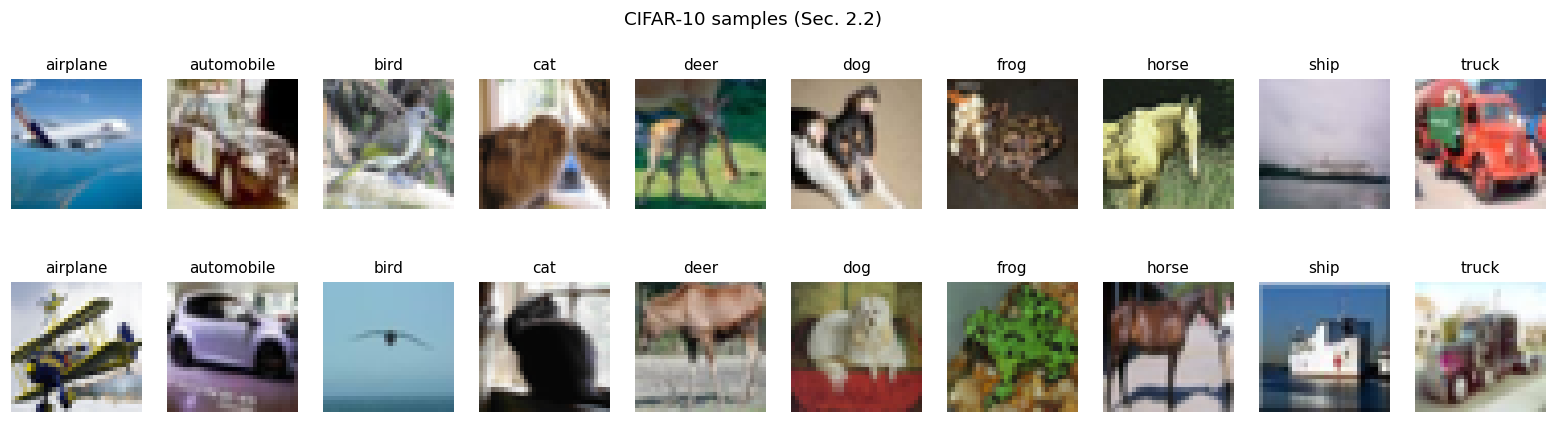

In [ ]:

# =============================================================================
# 1. CIFAR-10 FROM THE HUGGING FACE HUB  (Sec. 2.2)
# -----------------------------------------------------------------------------
# WHY THIS IS FAITHFUL:
#   - CIFAR-10 is one of the four datasets in Table 1 / Fig. 12.
#   - Validation data is carved out of the training split, as in the paper.
#   - Each image is flattened to 3072 real values for a dense network.
#   - Per-channel standardization (training statistics only) gives every input
#     feature roughly the same variance, which is the assumption behind the
#     variance analysis in Sec. 4.2.1 (all input features share Var[x]).
# WHAT IS SIMPLIFIED:
#   - Class-balanced subsets (10k / 2k / 2k) instead of 40k / 10k / 10k.
#   - 512 hidden units instead of 1000; 5 epochs instead of 5M updates.
# =============================================================================


print("Loading CIFAR-10 from the Hugging Face Hub ...")

t0 = time.time() # record the start time value (to measure how long this dataset load takes)
# passing repo name to load (fetch) our HF dataset of CIFAR-10 DATASET
raw = load_dataset(HF_DATASET) # dict dataset

# saftey check to get the actaul image name (img vs. image)
IMG_COL = "img" if "img" in raw["train"].column_names else "image"

LABEL_COL = "label" # setting our label column name to be label

CLASS_NAMES = list(raw["train"].features[LABEL_COL].names) # python list of class name (airplance, automobile)
# this var is used to size our final output layer (10 classes from cifar10 dataset)
NUM_CLASSES = len(CLASS_NAMES)                                   # 10

# listing all labels inside one numpy array
train_labels_all = np.array(raw["train"][LABEL_COL]) # np.array(0, 3, 9, 8, 7. ...)
test_labels_all = np.array(raw["test"][LABEL_COL]) # np.array(3, 4, 9, 8, 6)

# stratified means equally sampling (selecting) images for every single class alone
# 10 * 1000 = 10,000 training images
# this function will return the same number of smaples (example) inside every single class
def stratified_indices(labels, per_class, rng, exclude=None):
    """Draw `per_class` indices for every class, optionally excluding some."""
    out = [] # empty list that can contain those images

    for c in range(NUM_CLASSES):
        pool = np.where(labels == c)[0] # indices pool that containes many indicies

        if exclude is not None: # we would like to exclude someting !
            pool = np.setdiff1d(pool, exclude)

        out.append(rng.choice(pool, per_class, replace=False)) # this will select images (random number generator)

    out = np.concatenate(out) # convert python list into numpy array
    # shuffling our images (to randomize the sample order later on)
    rng.shuffle(out)
    return out # the final shuffled numpy array of the sample images

# define an RNG (to choose the sample)
rng = np.random.default_rng(SEED)

# you will get balanced dataset (the same number of smaples in each class)
# how many images do you want to put in each class
idx_train = stratified_indices(train_labels_all, N_TRAIN_PER_CLASS, rng)
# here we have the number of validation images set to be 200
# because we are extracting the validation images from within the training subset we have to exclude the training samples
# to prevent data leakage from training to validation we have to exclude them here (in the validation dataset split)
idx_val = stratified_indices(train_labels_all, N_VAL_PER_CLASS, rng, exclude=idx_train)
# testing images set to be = 200
idx_test = stratified_indices(test_labels_all, N_TEST_PER_CLASS, rng)

# convert the python list into numpy arry
def to_numpy(split, idx):
    """Decode the selected HF rows into a uint8 image array and a label array."""
    sub = raw[split].select(idx.tolist())
    # we are making sure that every single cifar-10 image is actually 3 channel (RGB)
    # uint8 is siutable with matplotlib library plotting standards
    imgs = np.stack([np.asarray(im.convert("RGB"), dtype=np.uint8) for im in sub[IMG_COL]])
    # return (images, labels of the datatype numpy int64)
    return imgs, np.array(sub[LABEL_COL], dtype=np.int64)


img_train, y_train = to_numpy("train", idx_train) # use to_numpy function to get images, label
img_val, y_val = to_numpy("train", idx_val) # we are subsetting the valiation dataset form the training dataset
img_test, y_test = to_numpy("test", idx_test)

# Per-channel standardization using TRAINING statistics only
# we have imagse in the range (0, 1) something important to have
CH_MEAN = (img_train / 255.0).mean(axis=(0, 1, 2)) # for every single channel we would have one average value
CH_STD = (img_train / 255.0).std(axis=(0, 1, 2)) # for every single channel we would have one single standard devidiation

# this function will standaridize our images into having mean=0, variance=1
def preprocess(imgs):
    # subtracting the mean (average) and dividing by STD
    x = (imgs.astype(np.float32) / 255.0 - CH_MEAN) / CH_STD
    # new shape (64, 3072 pixel) (32, 32, 3) 32*32*3=3072
    return x.reshape(len(imgs), -1).astype(np.float32)          # (N, 3072)

# preproccssed data sample by using our function preprocess
X_train, X_val, X_test = preprocess(img_train), preprocess(img_val), preprocess(img_test)
print(f"  done in {time.time() - t0:.1f}s")

# this class is an adpater that can adapt our HF dataset into pytorch dataset
class CIFARVectorDataset(Dataset):
    """Custom Dataset: each item is (flattened, standardized 3072-vector, class id)."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    # return how many exmaples exist in every single split
    def __len__(self):
        return len(self.y)
    # return one sample at a time (lazy loading)
    def __getitem__(self, i):
        return self.X[i], self.y[i] # return (image, label ) pair for later use to house inside dataloader object


train_ds = CIFARVectorDataset(X_train, y_train)
# validation loader to create datalaoder (setting a large batch size)
val_loader = DataLoader(CIFARVectorDataset(X_val, y_val), batch_size=250, shuffle=False)
test_loader = DataLoader(CIFARVectorDataset(X_test, y_test), batch_size=250, shuffle=False)

# this function will return the training dataloader
def make_train_loader(ds, epoch_seed):
    # for every epoch we would have a seprate different generator
    g = torch.Generator().manual_seed(epoch_seed) # 1001, 1002, 1003

    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)


# Fixed monitoring set (Sec. 3.1: 300 test examples)
# setting our monintoring dataset to compute the activation on it (fixed, constant dataset)
X_mon = torch.from_numpy(X_test[:N_MONITOR]).to(DEVICE)
y_mon = torch.from_numpy(y_test[:N_MONITOR]).to(DEVICE)

# ---------------------------- Sanity check -----------------------------------
xb0, yb0 = next(iter(make_train_loader(train_ds, SEED)))
print("\n=== DATA SANITY CHECK ===")
print(f"Source                 : {HF_DATASET} (Hugging Face Hub)")
print(f"Train / Val / Test     : {len(y_train)} / {len(y_val)} / {len(y_test)}   | monitor set: {N_MONITOR}")
print(f"One batch x shape      : {tuple(xb0.shape)}  (batch, 32*32*3)")
print(f"One batch y shape      : {tuple(yb0.shape)}")
print(f"Standardized x range   : [{X_train.min():.2f}, {X_train.max():.2f}], "
      f"mean {X_train.mean():.3f}, var {X_train.var():.3f}")
print(f"Channel mean / std     : {np.round(CH_MEAN, 3)} / {np.round(CH_STD, 3)}")
print(f"Label range            : {int(y_train.min())} .. {int(y_train.max())}")
print("Class vocabulary       :")
for c, name in enumerate(CLASS_NAMES):
    print(f"   {c}: {name:<11} train {int((y_train == c).sum()):>5} | val {int((y_val == c).sum()):>4}"
          f" | test {int((y_test == c).sum()):>4}")

fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(18, 4.4))
for c in range(NUM_CLASSES):
    idx = np.where(y_val == c)[0][:2]
    for r in range(2):
        ax = axes[r, c]
        ax.imshow(img_val[idx[r]])
        ax.set_title(CLASS_NAMES[c], color="black", fontsize=10)
        ax.axis("off")
fig.suptitle("CIFAR-10 samples (Sec. 2.2)", color="black")
show_fig(fig)

# Activation Functions (Glorot & Bengio, 2010, Sec. 2.3)

The paper compares three hidden-layer non-linearities. Each one tests a different idea about why deep networks are hard to train.

| Function | Idea it tests |
|---|---|
| **Sigmoid** | A non-zero mean causes saturation |
| **Tanh** | Symmetry around 0 helps |
| **Softsign** | Slower saturation helps even more |

---

## 1. Sigmoid

### Function

$$\sigma(s) = \frac{1}{1 + e^{-s}}$$

### Derivative

$$\sigma'(s) = \sigma(s)\,\big(1 - \sigma(s)\big)$$

### Key values

$$\sigma(0) = 0.5, \qquad \sigma'(0) = 0.25$$

$$\lim_{s \to -\infty} \sigma(s) = 0, \qquad \lim_{s \to +\infty} \sigma(s) = 1$$

### Properties

| Property | Value |
|---|---|
| Range | $(0, 1)$ |
| Value at 0 | $0.5$ |
| Maximum slope | $0.25$ |
| Symmetric around 0 | No |
| Tail behaviour | Exponential |

**Role in the paper:** An output of 0 is reached only when $s \to -\infty$, which is a saturated region. When training pushes the top layer toward 0, sigmoid units get stuck and block gradient flow (Fig. 2).

---

## 2. Hyperbolic Tangent (Tanh)

### Function

$$\tanh(s) = \frac{e^{s} - e^{-s}}{e^{s} + e^{-s}}$$

### Derivative

$$\tanh'(s) = 1 - \tanh^2(s)$$

### Key values

$$\tanh(0) = 0, \qquad \tanh'(0) = 1$$

$$\lim_{s \to -\infty} \tanh(s) = -1, \qquad \lim_{s \to +\infty} \tanh(s) = 1$$

### Relation to the sigmoid

$$\tanh(s) = 2\,\sigma(2s) - 1$$

Tanh is a shifted and stretched sigmoid. The shift that centres it on 0 is what makes the difference.

### Properties

| Property | Value |
|---|---|
| Range | $(-1, 1)$ |
| Value at 0 | $0$ |
| Maximum slope | $1$ |
| Symmetric around 0 | Yes |
| Tail behaviour | Exponential |

**Role in the paper:** Because $\tanh(0) = 0$, pushing outputs toward 0 keeps units in their most active region. With standard initialization, however, tanh layers still saturate one after another, starting from layer 1 (Fig. 3).

---

## 3. Softsign

### Function

$$\text{softsign}(s) = \frac{s}{1 + \lvert s \rvert}$$

### Derivative

$$\text{softsign}'(s) = \frac{1}{\left(1 + \lvert s \rvert\right)^2}$$

### Derivation (for $s > 0$, quotient rule)

$$\frac{d}{ds}\left(\frac{s}{1+s}\right) = \frac{(1)(1+s) - s(1)}{(1+s)^2} = \frac{1}{(1+s)^2}$$

The case $s < 0$ is symmetric, which gives the $\lvert s \rvert$ in the general formula.

### Key values

$$\text{softsign}(0) = 0, \qquad \text{softsign}'(0) = 1$$

$$\lim_{s \to -\infty} \text{softsign}(s) = -1, \qquad \lim_{s \to +\infty} \text{softsign}(s) = 1$$

### Properties

| Property | Value |
|---|---|
| Range | $(-1, 1)$ |
| Value at 0 | $0$ |
| Maximum slope | $1$ |
| Symmetric around 0 | Yes |
| Tail behaviour | Polynomial (much slower) |

**Role in the paper:** Softsign saturates far more slowly than tanh. Its units settle at the "knees" (about $\pm 0.6$ to $\pm 0.8$), where they are non-linear but still pass gradients (Fig. 4).

---

## 4. Tail Behaviour: Why Softsign Saturates Less

For large $\lvert s \rvert$, the slopes decay at very different rates:

$$\tanh'(s) \approx 4\,e^{-2\lvert s \rvert} \qquad \text{(exponential decay)}$$

$$\text{softsign}'(s) \approx \frac{1}{s^2} \qquad \text{(polynomial decay)}$$

$$\sigma'(s) \approx e^{-\lvert s \rvert} \qquad \text{(exponential decay)}$$

Exponential decay collapses much faster than polynomial decay, so tanh and sigmoid units lose their gradient far sooner than softsign units.

### Output values

| $s$ | $\tanh(s)$ | $\text{softsign}(s)$ |
|---|---|---|
| 1 | 0.762 | 0.500 |
| 2 | 0.964 | 0.667 |
| 3 | 0.995 | 0.750 |
| 5 | 0.9999 | 0.833 |
| 10 | ≈ 1.0000 | 0.909 |

### Slope values

| $s$ | $\sigma'(s)$ | $\tanh'(s)$ | $\text{softsign}'(s)$ |
|---|---|---|---|
| 0 | 0.250 | 1.000 | 1.000 |
| 1 | 0.197 | 0.420 | 0.250 |
| 2 | 0.105 | 0.071 | 0.111 |
| 3 | 0.045 | 0.0099 | 0.063 |
| 5 | 0.0066 | 0.00018 | 0.028 |

---

## 5. Connection to the Variance Analysis

The paper's derivation (Sec. 4.2.1) assumes a **linear regime** at initialization:

$$f'(s) \approx 1 \quad \text{near } s = 0$$

| Function | $f'(0)$ | Assumption holds? |
|---|---|---|
| Sigmoid | $0.25$ | No |
| Tanh | $1$ | Yes |
| Softsign | $1$ | Yes |

This is why the normalized initialization is derived for symmetric activations with unit slope at 0, and why the sigmoid falls outside the analysis.

---

## 6. Role of the Derivatives in the Lab

During training, PyTorch's autograd computes gradients automatically. The hand-written derivatives are used for the **layer Jacobian** diagnostic (Eq. 17):

$$J^i = \frac{\partial z^{i+1}}{\partial z^i} = \mathrm{diag}\!\left(f'(s^i)\right) W^{i+1}$$

Its average singular value measures how well signal is preserved between layers. A value of 1 is ideal.

---

## Summary

| Function | Formula | Range | $f'(0)$ | Tails | Paper finding |
|---|---|---|---|---|---|
| Sigmoid | $\frac{1}{1+e^{-s}}$ | $(0, 1)$ | $0.25$ | Exponential | Top layer saturates at 0 (Fig. 2) |
| Tanh | $\frac{e^{s}-e^{-s}}{e^{s}+e^{-s}}$ | $(-1, 1)$ | $1$ | Exponential | Layers saturate sequentially (Fig. 3) |
| Softsign | $\frac{s}{1+\lvert s \rvert}$ | $(-1, 1)$ | $1$ | Polynomial | Settles at the knees (Fig. 4) |

> **Suggested plot:** Two panels over $s \in [-6, 6]$, with the three functions on the left and their derivatives on the right. The derivative panel makes the exponential-versus-polynomial tail difference clear at a glance.

In [ ]:
# =============================================================================
# 2. ACTIVATION FUNCTIONS (Sec. 2.3), from first principles
# =============================================================================
# the paper uses 3 main activation functions
# 1. Sigmoid activation function
# 2. Tanh (Hyperbolic tangent) activation function
# 3. SoftSign Activation Function

# this is sigmoid function euquation
# sigmoid is non-zero centerd function (sigmoid can not hold for deep architecture)
def sigmoid_fn(s):  return 1.0 / (1.0 + torch.exp(-s))            # 1/(1+e^-x)

# define the tanh activation function equation (pytorch's built-in tanh function)
# symmetric around 0 (it can stay not saturating for a while)
# but as you scale the archectuure deep and deep it will start to staturate
def tanh_fn(s):     return torch.tanh(s)                            # tanh(x)

# this function is actaully gentler in the tails of the activation function curve
def softsign_fn(s): return s / (1.0 + s.abs())                      # x/(1+|x|)

def sigmoid_grad(s):  z = sigmoid_fn(s); return z * (1.0 - z) # derivative of the sigmoid function
def tanh_grad(s):     z = torch.tanh(s); return 1.0 - z * z # derivative of tanh function
def softsign_grad(s): return 1.0 / (1.0 + s.abs()) ** 2 # derivative of softsign function

# return the actual activation function required by us
ACTIVATIONS = {"sigmoid": sigmoid_fn, "tanh": tanh_fn, "softsign": softsign_fn}
# return the gradient of the activatino function required
ACTIVATION_GRADS = {"sigmoid": sigmoid_grad, "tanh": tanh_grad, "softsign": softsign_grad}

In [ ]:
# =============================================================================
# 3. MODEL: deep feedforward network (Sec. 2.3, Sec. 4.2.1)
#    s^i = z^i W^i + b^i ,   z^{i+1} = f(s^i) ,   output softmax(b + W h)
# =============================================================================
class DeepFeedforwardNet(nn.Module):
    # this method init builds the layers and defines them
    def __init__(self, in_dim, hidden, n_hidden, n_classes, activation, init_scheme):
        # this function is used to define the layer with thier pre-defines settings
        super().__init__()
        self.activation_name = activation

        self.act = ACTIVATIONS[activation] # this attribute is what get really used in the forward method
        # the derivative of the activation function used later on for Jacobian matrix
        self.act_grad = ACTIVATION_GRADS[activation]

        self.init_scheme = init_scheme # either glorot/standard default inti

        # hidden = 512 number of hidden units
        # n_hidden = 5 number of hidden layers each layer will contain 512 neurons
        # in_dim = 3072 number of pixel in every single flattened vector
        dims = [in_dim] + [hidden] * n_hidden
        # this list is creating the layer fully-conncted hiden layer for our architecture
        # if you use normal defualt python list pytorch will not be aware of the layer inside it
        # we are using a specialied pytorch module list class that can compute gradients and train the layers later on
        # 1. device transfer .to(device)
        # 2. allow autograd to compute gradients
        # 3. make pytorch save the weights
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(n_hidden)])
        # this output layer will map our hidden space into output logits space
        self.out = nn.Linear(hidden, n_classes)            # softmax logistic regression
        # this function will reset the weights to standard/glorot init
        self.reset_parameters()

    def reset_parameters(self):
        # iterate through every single layer architecture (standard/glorot)
        for lin in list(self.layers) + [self.out]:
            # fan_in, fan_out
            # fan_in is the number of input features to the model
            # fan_out is the number of output feature from the model
            n_in, n_out = lin.in_features, lin.out_features

            if self.init_scheme == "standard":
                # the standard way of initializing our weights
                a = 1.0 / math.sqrt(n_in)                              # Eq. 1
            else:
                # the actual glorot init/Xavier inti
                a = math.sqrt(6.0) / math.sqrt(n_in + n_out)           # Eq. 16

            # we have to exclude the initiailization from learning (training)
            with torch.no_grad(): # disable our gradient tracking
                lin.weight.uniform_(-a, a) # init our weights from a uniform dist
                lin.bias.zero_()  # do it right now (in place)                                     # Sec. 2.3
    # this method will define the forward compuation (X runs through the network)
    def forward(self, x, record=False):
        # record=False, training/evaluting without recording
        # record=True, doing record saving to later visualize those activation/gradients
        z = x # our initial is actually the same as our x
        pre, post = [], []

        for lin in self.layers:
            # compute the weighted sum of Z
            # Z * W + B = s
            s = lin(z)                          # s^i = z^i W^i + b^i

            # checking if the S weighted sum is actually able to compute gradients
            if record and s.requires_grad:
                # pytorch by default discard that gradient value becuase it will try to save memory
                s.retain_grad()                 # exposes dCost/ds^i
            z = self.act(s)                     # z^{i+1} = f(s^i)

            if record:
                pre.append(s)
                post.append(z)

        logits = self.out(z) # this layer produces one score per class (logits)

        return (logits, pre, post) if record else logits


# this loss function is the actual one implement in the paper (Glorot init)
def nll_loss(logits, y):
    """Conditional negative log-likelihood -log P(y|x) with softmax (Sec. 2.3)."""
    # this function compute conditional negative log-liklihood
    # converting our logits into log-probabilites
    log_probs = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    # return the mean (average) value of our logits compared to the ground truth target
    return -log_probs.gather(1, y.unsqueeze(1)).mean()

# this function will run complete pass to the model (compute prediction) and optimize our weights
def sgd_step(model, xb, yb, lr):
    """One plain SGD update: theta <- theta - eps * g, g averaged over 10 pairs."""
    # this function will go through the training steps of pytorch
    # 1. Forward Pass (compute prediction)
    # 2. Loss (measure how wrong they are)
    # 3. Clear old gradients (to start fresh)
    # 4. Backpropagte (to compute the new graidents)
    # 5. One optimizer step (move our weights one step to make them more accurate)

    logits = model(xb) # compute predictions

    loss = nll_loss(logits, yb) # measure how wrong they wrong are

    model.zero_grad(set_to_none=True) # to start from scratch compute new gradients

    loss.backward() # call will compute the new gradients of the loss w.r.t our wieghts/biases

    with torch.no_grad(): # turning of our gradients calculation track

        for p in model.parameters():
            p.add_(p.grad, alpha=-lr)

    return loss.item(), (logits.argmax(1) == yb).sum().item() # return loss, accuracy

In [ ]:
# =============================================================================
# 4. DIAGNOSTIC TOOLS FROM THE PAPER
# =============================================================================
@torch.no_grad()
def activation_stats(model, X):
    """Per-layer mean, std, 2nd / 98th percentiles of activations (Figs. 2, 3, 10)."""
    _, _, post = model(X, record=True)
    out = {"mean": [], "std": [], "p02": [], "p98": []}
    for z in post:
        f = z.flatten().float()
        out["mean"].append(f.mean().item())
        out["std"].append(f.std().item())
        out["p02"].append(torch.quantile(f, 0.02).item())
        out["p98"].append(torch.quantile(f, 0.98).item())
    return {k: np.array(v) for k, v in out.items()}


def gradient_probe(model, X, y, keep_values=False):
    """Back-propagated gradients dCost/ds^i (Eq. 2) and weight gradients (Eq. 3).
    Summed per-example cost, so dCost/ds^i is a per-example gradient."""
    model.zero_grad(set_to_none=True)
    logits, pre, post = model(X, record=True)
    (nll_loss(logits, y) * X.shape[0]).backward()
    back = [s.grad.detach().flatten().cpu().numpy() for s in pre]
    wgrad = [lin.weight.grad.detach().flatten().cpu().numpy() for lin in model.layers]
    res = {"back_std": np.array([b.std() for b in back]),
           "wgrad_std": np.array([w.std() for w in wgrad])}
    if keep_values:
        res["back"], res["wgrad"] = back, wgrad
        res["acts"] = [z.detach().flatten().cpu().numpy() for z in post]
    model.zero_grad(set_to_none=True)
    return res


@torch.no_grad()
def jacobian_mean_singular_values(model, X, n_examples=JACOBIAN_EXAMPLES):
    """Average singular value of J^i = dz^{i+1}/dz^i (Eq. 17) between equal-width
    hidden layers. For z^{i+1} = f(z^i W^T + b):  J^i = diag(f'(s^i)) W."""
    _, pre, _ = model(X[:n_examples], record=True)
    res = []
    for i in range(1, len(model.layers)):
        W = model.layers[i].weight                              # (out, in)
        J = model.act_grad(pre[i]).unsqueeze(2) * W.unsqueeze(0)  # (n, out, in)
        res.append(torch.linalg.svdvals(J).mean().item())
    return np.array(res)


@torch.no_grad()
def evaluate(model, loader):
    """NLL, accuracy, error (%) (paper metric), predictions, confidences."""
    tot, n = 0.0, 0
    P, Y, C = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        tot += nll_loss(logits, yb).item() * len(yb)
        n += len(yb)
        conf, pred = torch.softmax(logits, dim=1).max(dim=1)
        P.append(pred.cpu()); Y.append(yb.cpu()); C.append(conf.cpu())
    preds, labels, confs = torch.cat(P).numpy(), torch.cat(Y).numpy(), torch.cat(C).numpy()
    acc = float((preds == labels).mean())
    return {"loss": tot / n, "acc": acc, "error": 100.0 * (1.0 - acc),
            "preds": preds, "labels": labels, "conf": confs}


def per_class_accuracy(preds, labels):
    return np.array([(preds[labels == c] == c).mean() if np.any(labels == c) else np.nan
                     for c in range(NUM_CLASSES)])


def confusion_matrix_norm(preds, labels):
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES))
    for t, p in zip(labels, preds):
        cm[t, p] += 1
    return cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)


def saturation_fraction(z, activation):
    """Share of units near an asymptote. Sigmoid: z<0.05 or z>0.95;
    tanh / softsign: |z|>0.95 (softsign needs |s|>19, its gentler saturation, Sec. 3.3)."""
    if activation == "sigmoid":
        return float(np.mean((z < 0.05) | (z > 0.95)))
    return float(np.mean(np.abs(z) > 0.95))


def density_line(ax, values, bins, label, color):
    h, edges = np.histogram(values, bins=bins, density=True)
    ax.plot(0.5 * (edges[:-1] + edges[1:]), h, label=label, color=color, lw=1.3)



=== GRADIENTS AT INITIALIZATION (tanh network, Sec. 4.2) ===
Layer   n*Var[W] std  n*Var[W] norm  std dC/ds std  std dC/ds norm
1              0.333          1.715         0.0020          0.0203
2              0.334          1.001         0.0043          0.0317
3              0.334          1.002         0.0079          0.0406
4              0.333          1.000         0.0139          0.0479
5              0.334          1.001         0.0242          0.0543
(Layer 1: fan-in 3072, fan-out 512, so Eq. 16 gives n*Var = 2*3072/(3072+512).)
Average Jacobian singular value (Eq. 17): standard = 0.480, normalized = 0.711   (paper: ~0.5 vs ~0.8)


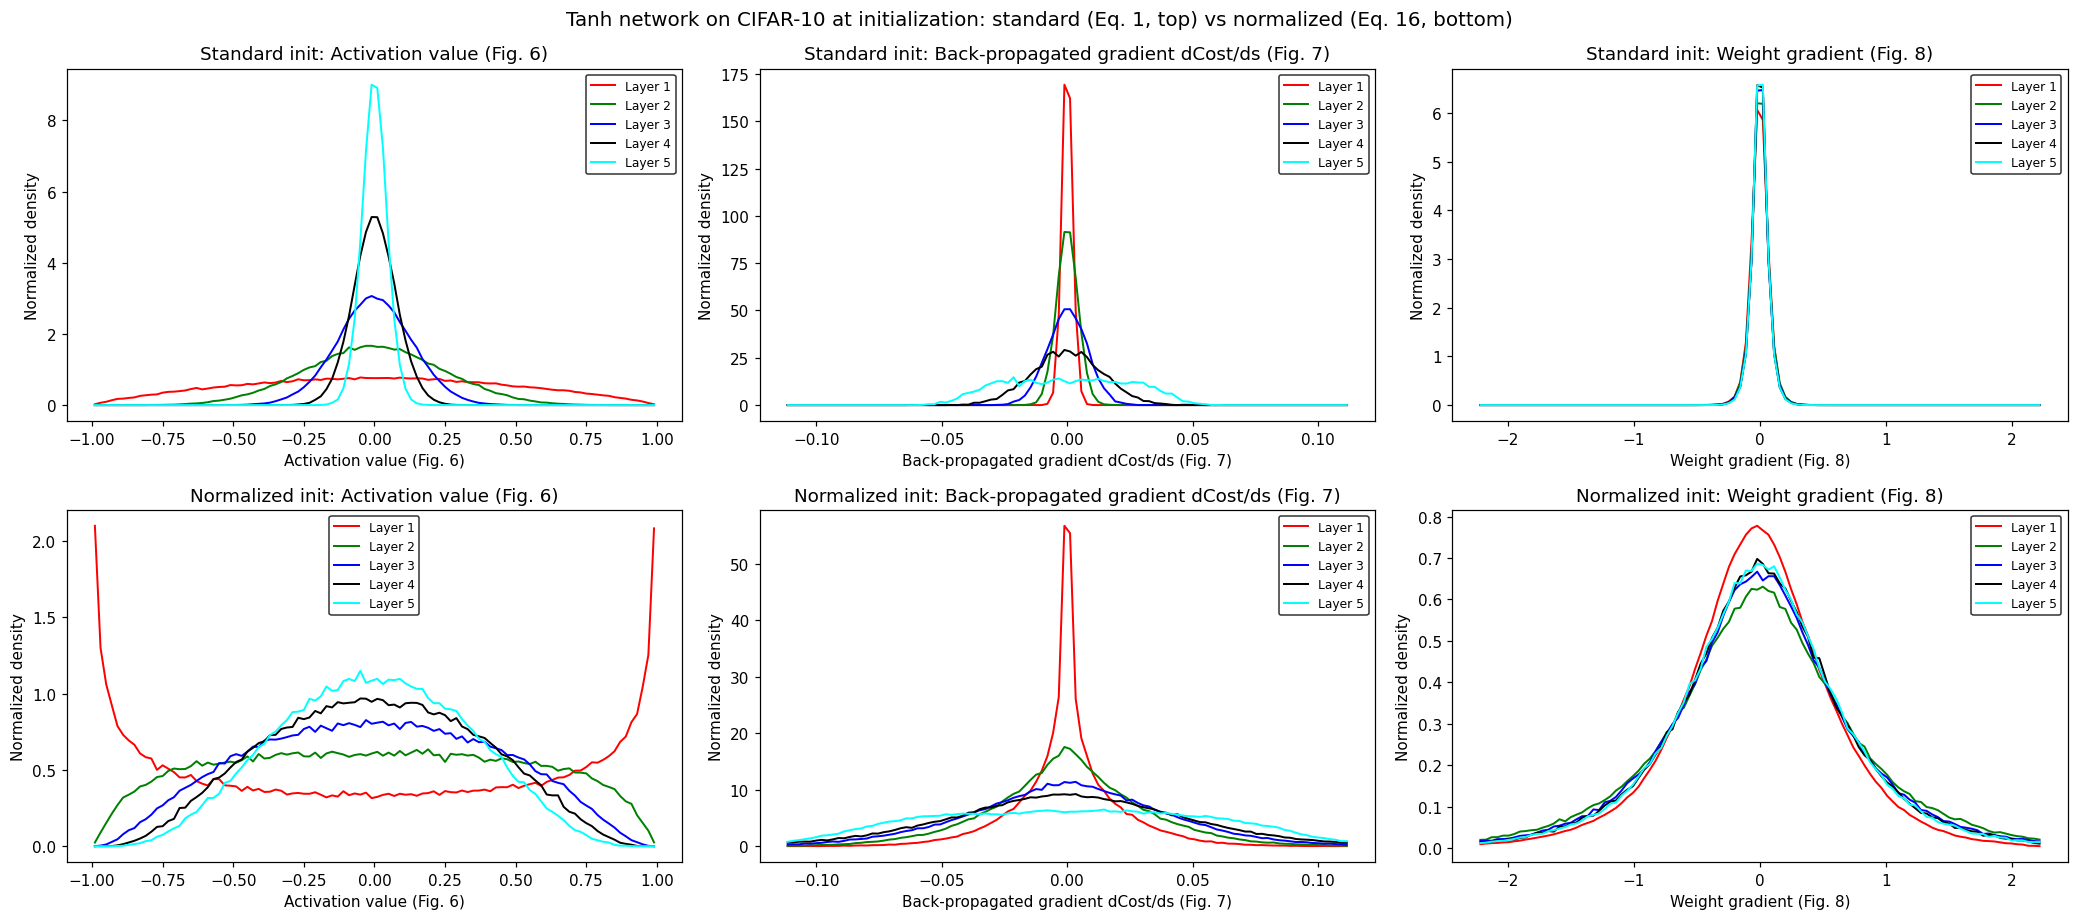

In [ ]:
# =============================================================================
# 5. GRADIENTS AT INITIALIZATION: standard vs normalized (Sec. 4.2)
#    Eq. 15: standard init gives n*Var[W] = 1/3 per layer.
#    Eq. 12/16: normalized init gives n*Var[W] = 1 for equal-width layers.
# =============================================================================
SCHEMES = ["standard", "normalized"]

init_study = {}
for scheme in SCHEMES:
    set_seed(SEED)
    m = DeepFeedforwardNet(IN_DIM, HIDDEN, N_HIDDEN_LAYERS, NUM_CLASSES, "tanh", scheme).to(DEVICE)
    init_study[scheme] = {
        "probe": gradient_probe(m, X_mon, y_mon, keep_values=True),
        "jac": jacobian_mean_singular_values(m, X_mon),
        "nvar": np.array([lin.in_features * lin.weight.var().item() for lin in m.layers]),
    }

print("\n=== GRADIENTS AT INITIALIZATION (tanh network, Sec. 4.2) ===")
print(f"{'Layer':<6}{'n*Var[W] std':>14}{'n*Var[W] norm':>15}{'std dC/ds std':>15}{'std dC/ds norm':>16}")
for i in range(N_HIDDEN_LAYERS):
    print(f"{i+1:<6}{init_study['standard']['nvar'][i]:>14.3f}{init_study['normalized']['nvar'][i]:>15.3f}"
          f"{init_study['standard']['probe']['back_std'][i]:>15.4f}"
          f"{init_study['normalized']['probe']['back_std'][i]:>16.4f}")
print(f"(Layer 1: fan-in {IN_DIM}, fan-out {HIDDEN}, so Eq. 16 gives n*Var = 2*{IN_DIM}/({IN_DIM}+{HIDDEN}).)")
print(f"Average Jacobian singular value (Eq. 17): standard = {init_study['standard']['jac'].mean():.3f}, "
      f"normalized = {init_study['normalized']['jac'].mean():.3f}   (paper: ~0.5 vs ~0.8)")

fig, axes = plt.subplots(2, 3, figsize=(19, 8.5))
cols = [("acts", "Activation value (Fig. 6)"),
        ("back", "Back-propagated gradient dCost/ds (Fig. 7)"),
        ("wgrad", "Weight gradient (Fig. 8)")]
for col, (key, xlabel) in enumerate(cols):
    if key == "acts":
        lim = 1.0
    else:
        allv = np.concatenate([np.concatenate(init_study[s]["probe"][key]) for s in SCHEMES])
        lim = np.percentile(np.abs(allv), 99.5)
    bins = np.linspace(-lim, lim, 101)
    for row, scheme in enumerate(SCHEMES):
        ax = axes[row, col]
        for li, vals in enumerate(init_study[scheme]["probe"][key]):
            density_line(ax, vals, bins, f"Layer {li+1}", LAYER_COLORS[li])
        ax.set_title(f"{scheme.capitalize()} init: {xlabel}")
        ax.set_xlabel(xlabel); ax.set_ylabel("Normalized density"); ax.legend(fontsize=8)
        style_ax(ax)
fig.suptitle("Tanh network on CIFAR-10 at initialization: standard (Eq. 1, top) vs normalized (Eq. 16, bottom)",
             color="black", fontsize=13)
fig.tight_layout()
show_fig(fig)


In [ ]:
# =============================================================================
# 6. CONFIGURATIONS OF TABLE 1 + PER-MODEL LEARNING-RATE SELECTION
#    Sec. 2.3: "the learning rate eps is a hyper-parameter that is optimized
#    based on validation set error", separately for each model.
# =============================================================================
CONFIGS = [  # (display name, activation, init)   "N" = normalized init
    ("Sigmoid",    "sigmoid",  "standard"),
    ("Tanh",       "tanh",     "standard"),
    ("Tanh N",     "tanh",     "normalized"),
    ("Softsign",   "softsign", "standard"),
    ("Softsign N", "softsign", "normalized"),
]
PRIMARY = "Tanh N"   # best CIFAR-10 configuration in Table 1

sweep_ds = CIFARVectorDataset(X_train[:LR_SWEEP_EXAMPLES], y_train[:LR_SWEEP_EXAMPLES])


def lr_sweep_score(activation, init_scheme, lr):
    """One short pass over a training slice, then validation error (%)."""
    set_seed(SEED)
    model = DeepFeedforwardNet(IN_DIM, HIDDEN, N_HIDDEN_LAYERS, NUM_CLASSES,
                               activation, init_scheme).to(DEVICE)
    for xb, yb in make_train_loader(sweep_ds, SEED):
        loss_val, _ = sgd_step(model, xb.to(DEVICE), yb.to(DEVICE), lr)
        if not math.isfinite(loss_val):
            return float("inf")                 # diverged
    return evaluate(model, val_loader)["error"]


print("\n=== LEARNING-RATE SELECTION ON VALIDATION ERROR (Sec. 2.3) ===")
best_lr, lr_table = {}, {}
for name, act, init in CONFIGS:
    scores = {lr: lr_sweep_score(act, init, lr) for lr in LR_GRID}
    lr_table[name] = scores
    best_lr[name] = min(scores, key=scores.get)
    print(f"  {name:<11} " + "  ".join(f"lr={lr:<6} err={e:6.2f}%" for lr, e in scores.items())
          + f"   -> chosen {best_lr[name]}")


=== LEARNING-RATE SELECTION ON VALIDATION ERROR (Sec. 2.3) ===
  Sigmoid     lr=0.003  err= 90.00%  lr=0.01   err= 90.00%  lr=0.03   err= 90.00%  lr=0.1    err= 90.00%   -> chosen 0.003
  Tanh        lr=0.003  err= 79.20%  lr=0.01   err= 70.30%  lr=0.03   err= 69.15%  lr=0.1    err= 72.45%   -> chosen 0.03
  Tanh N      lr=0.003  err= 66.30%  lr=0.01   err= 66.05%  lr=0.03   err= 70.85%  lr=0.1    err= 77.10%   -> chosen 0.01
  Softsign    lr=0.003  err= 78.35%  lr=0.01   err= 79.80%  lr=0.03   err= 71.05%  lr=0.1    err= 70.35%   -> chosen 0.1
  Softsign N  lr=0.003  err= 70.55%  lr=0.01   err= 65.80%  lr=0.03   err= 67.25%  lr=0.1    err= 71.00%   -> chosen 0.01


In [ ]:
# =============================================================================
# 7. TRAINING (5 epochs per configuration)
# =============================================================================
UPDATES_PER_EPOCH = len(train_ds) // BATCH_SIZE # number of updates per epoch
# how often will you create chekcpoints during the training loop
CKPT_EVERY = max(1, UPDATES_PER_EPOCH // CHECKPOINTS_PER_EPOCH)


def record_checkpoint(model, hist, x_epoch):
    # this function will compute the history of the checkpoints
    # append the necessary information of the model checkpoints
    hist["ckpt_x"].append(x_epoch)
    hist["act"].append(activation_stats(model, X_mon))
    p = gradient_probe(model, X_mon, y_mon)
    hist["wgrad_std"].append(p["wgrad_std"])
    hist["back_std"].append(p["back_std"])


def train_config(name, activation, init_scheme, lr):
    set_seed(SEED) # set all random seed settings

    model = DeepFeedforwardNet(IN_DIM, HIDDEN, N_HIDDEN_LAYERS, NUM_CLASSES,
                               activation, init_scheme).to(DEVICE) # move to the target device (CPU/GPU)

    # this will contain our metrics/statisitics of the checkpoint
    hist = {k: [] for k in ["train_loss", "train_err", "val_loss", "val_err", "val_per_class",
                            "ckpt_x", "act", "wgrad_std", "back_std", "jac_x", "jac"]}


    record_checkpoint(model, hist, 0.0)

    hist["jac_x"].append(0.0); hist["jac"].append(jacobian_mean_singular_values(model, X_mon))

    best_state, best_err, step, diverged = copy.deepcopy(model.state_dict()), float("inf"), 0, False

    # iterate through one by one to train the model
    for epoch in range(EPOCHS):
        run_loss, run_correct, n = 0.0, 0, 0
        # inner for loop to iterate tourugh our data loader one batch a time
        for xb, yb in make_train_loader(train_ds, SEED + epoch):
            # this function beautiflly injects the training steps into one function call
            loss_val, correct = sgd_step(model, xb.to(DEVICE), yb.to(DEVICE), lr)

            if not math.isfinite(loss_val): # this loss value has reached infinit value (somethign wrong the loss)
                diverged = True
                break # exit out the loop

            run_loss += loss_val * len(yb) # convert the mean loss value into a sum of the loss

            run_correct += correct;
            n += len(yb) # how many samples we have processed so far

            step += 1
            # we are saving 5 checkpoint per epochs
            # how often we have checkpoints per epoch (every 200 steps) (we will run 1000)
            # 200 - 400 - 600 - 800 - 1000
            if step % CKPT_EVERY == 0: # it's time to save a checkpoint
                record_checkpoint(model, hist, step / UPDATES_PER_EPOCH)
        if diverged:
            print(f"  [{name:<10}] diverged in epoch {epoch+1}; stopping this configuration.")
            break


        hist["jac_x"].append(epoch + 1.0)
        hist["jac"].append(jacobian_mean_singular_values(model, X_mon))
        val = evaluate(model, val_loader)
        hist["train_loss"].append(run_loss / n)
        hist["train_err"].append(100.0 * (1 - run_correct / n))
        hist["val_loss"].append(val["loss"])
        hist["val_err"].append(val["error"])
        hist["val_per_class"].append(per_class_accuracy(val["preds"], val["labels"]))

        if val["error"] < best_err:                      # model selection on validation error
            best_err, best_state = val["error"], copy.deepcopy(model.state_dict())
        print(f"  [{name:<10}] epoch {epoch+1}/{EPOCHS} | train NLL {hist['train_loss'][-1]:.4f} "
              f"err {hist['train_err'][-1]:6.2f}% | val NLL {val['loss']:.4f} err {val['error']:6.2f}%")
    return model, best_state, hist


results = {}
print("\n=== TRAINING ===")
for name, act, init in CONFIGS:
    t0 = time.time()
    final_model, best_state, hist = train_config(name, act, init, best_lr[name])

    # Training-dynamics diagnostics use the FINAL model (end of training, Fig. 4)
    with torch.no_grad():
        _, _, post = final_model(X_mon, record=True)
    final_acts = [z.flatten().cpu().numpy() for z in post]

    # Test metrics use the checkpoint with the best validation error
    best_model = DeepFeedforwardNet(IN_DIM, HIDDEN, N_HIDDEN_LAYERS, NUM_CLASSES, act, init).to(DEVICE)
    best_model.load_state_dict(best_state)
    test = evaluate(best_model, test_loader)

    results[name] = {"model": best_model, "hist": hist, "test": test, "activation": act,
                     "lr": best_lr[name], "final_acts": final_acts,
                     "saturation": np.array([saturation_fraction(z, act) for z in final_acts])}
    print(f"  [{name:<10}] TEST error {test['error']:.2f}%  NLL {test['loss']:.4f}  "
          f"(paper: {PAPER_CIFAR10_ERR[name]:.2f}%)  [{time.time()-t0:.1f}s]\n")


=== TRAINING ===
  [Sigmoid   ] epoch 1/5 | train NLL 2.3135 err  90.36% | val NLL 2.3075 err  90.00%
  [Sigmoid   ] epoch 2/5 | train NLL 2.3115 err  90.02% | val NLL 2.3085 err  90.00%
  [Sigmoid   ] epoch 3/5 | train NLL 2.3124 err  90.25% | val NLL 2.3097 err  90.00%
  [Sigmoid   ] epoch 4/5 | train NLL 2.3128 err  90.31% | val NLL 2.3133 err  90.00%
  [Sigmoid   ] epoch 5/5 | train NLL 2.3122 err  90.04% | val NLL 2.3100 err  90.00%
  [Sigmoid   ] TEST error 90.00%  NLL 2.3075  (paper: 57.28%)  [24.4s]

  [Tanh      ] epoch 1/5 | train NLL 1.9263 err  69.36% | val NLL 1.8173 err  65.05%
  [Tanh      ] epoch 2/5 | train NLL 1.7595 err  62.85% | val NLL 1.7582 err  61.30%
  [Tanh      ] epoch 3/5 | train NLL 1.6690 err  58.97% | val NLL 1.7663 err  62.75%
  [Tanh      ] epoch 4/5 | train NLL 1.5841 err  55.00% | val NLL 1.7570 err  60.60%
  [Tanh      ] epoch 5/5 | train NLL 1.5019 err  52.11% | val NLL 1.7780 err  60.15%
  [Tanh      ] TEST error 60.50%  NLL 1.7945  (paper: 55.90%

In [ ]:
# =============================================================================
# 8. TABLE 1 ANALOGUE + SIGNIFICANCE TEST
#    The paper reports significance at p = 0.005 without naming the test. All
#    models are scored on the SAME test images, so a paired McNemar test fits.
# =============================================================================
def mcnemar(pred_a, pred_b, labels):
    a_ok, b_ok = pred_a == labels, pred_b == labels
    b = int(np.sum(a_ok & ~b_ok)); c = int(np.sum(~a_ok & b_ok))
    if b + c == 0:
        return b, c, 1.0
    stat = (abs(b - c) - 1) ** 2 / (b + c)          # chi-square (1 dof), continuity-corrected
    return b, c, math.erfc(math.sqrt(stat / 2.0))

print("=== TABLE 1 ANALOGUE: CIFAR-10 test error (%) ===")
print(f"{'TYPE':<12}{'LR':>8}{'Ours %':>10}{'Paper %':>10}{'Test NLL':>11}")
for name, _, _ in CONFIGS:
    r = results[name]
    print(f"{name:<12}{r['lr']:>8}{r['test']['error']:>10.2f}{PAPER_CIFAR10_ERR[name]:>10.2f}{r['test']['loss']:>11.4f}")
for a, b in [("Tanh", "Tanh N"), ("Softsign", "Softsign N"), ("Sigmoid", "Tanh N")]:
    n_a, n_b, p = mcnemar(results[a]["test"]["preds"], results[b]["test"]["preds"], y_test)
    verdict = "significant" if p < 0.005 else "not significant"
    print(f"McNemar {a} vs {b}: only-{a}-correct={n_a}, only-{b}-correct={n_b}, "
          f"p={p:.4g} ({verdict} at p=0.005)")

=== TABLE 1 ANALOGUE: CIFAR-10 test error (%) ===
TYPE              LR    Ours %   Paper %   Test NLL
Sigmoid        0.003     90.00     57.28     2.3075
Tanh            0.03     60.50     55.90     1.7945
Tanh N          0.01     61.25     52.92     1.8989
Softsign         0.1     61.50     55.78     1.7980
Softsign N      0.01     59.80     53.80     1.7268
McNemar Tanh vs Tanh N: only-Tanh-correct=160, only-Tanh N-correct=145, p=0.4228 (not significant at p=0.005)
McNemar Softsign vs Softsign N: only-Softsign-correct=113, only-Softsign N-correct=147, p=0.0407 (not significant at p=0.005)
McNemar Sigmoid vs Tanh N: only-Sigmoid-correct=91, only-Tanh N-correct=666, p=1.177e-96 (significant at p=0.005)


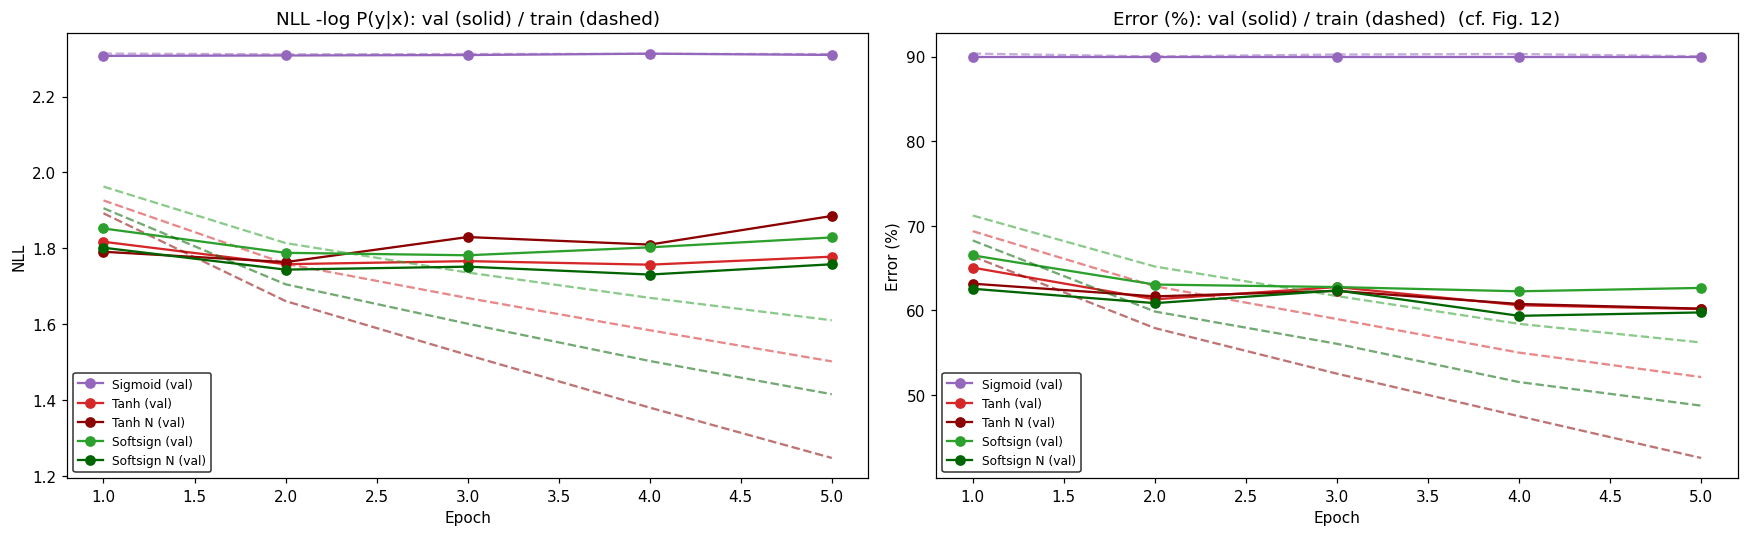

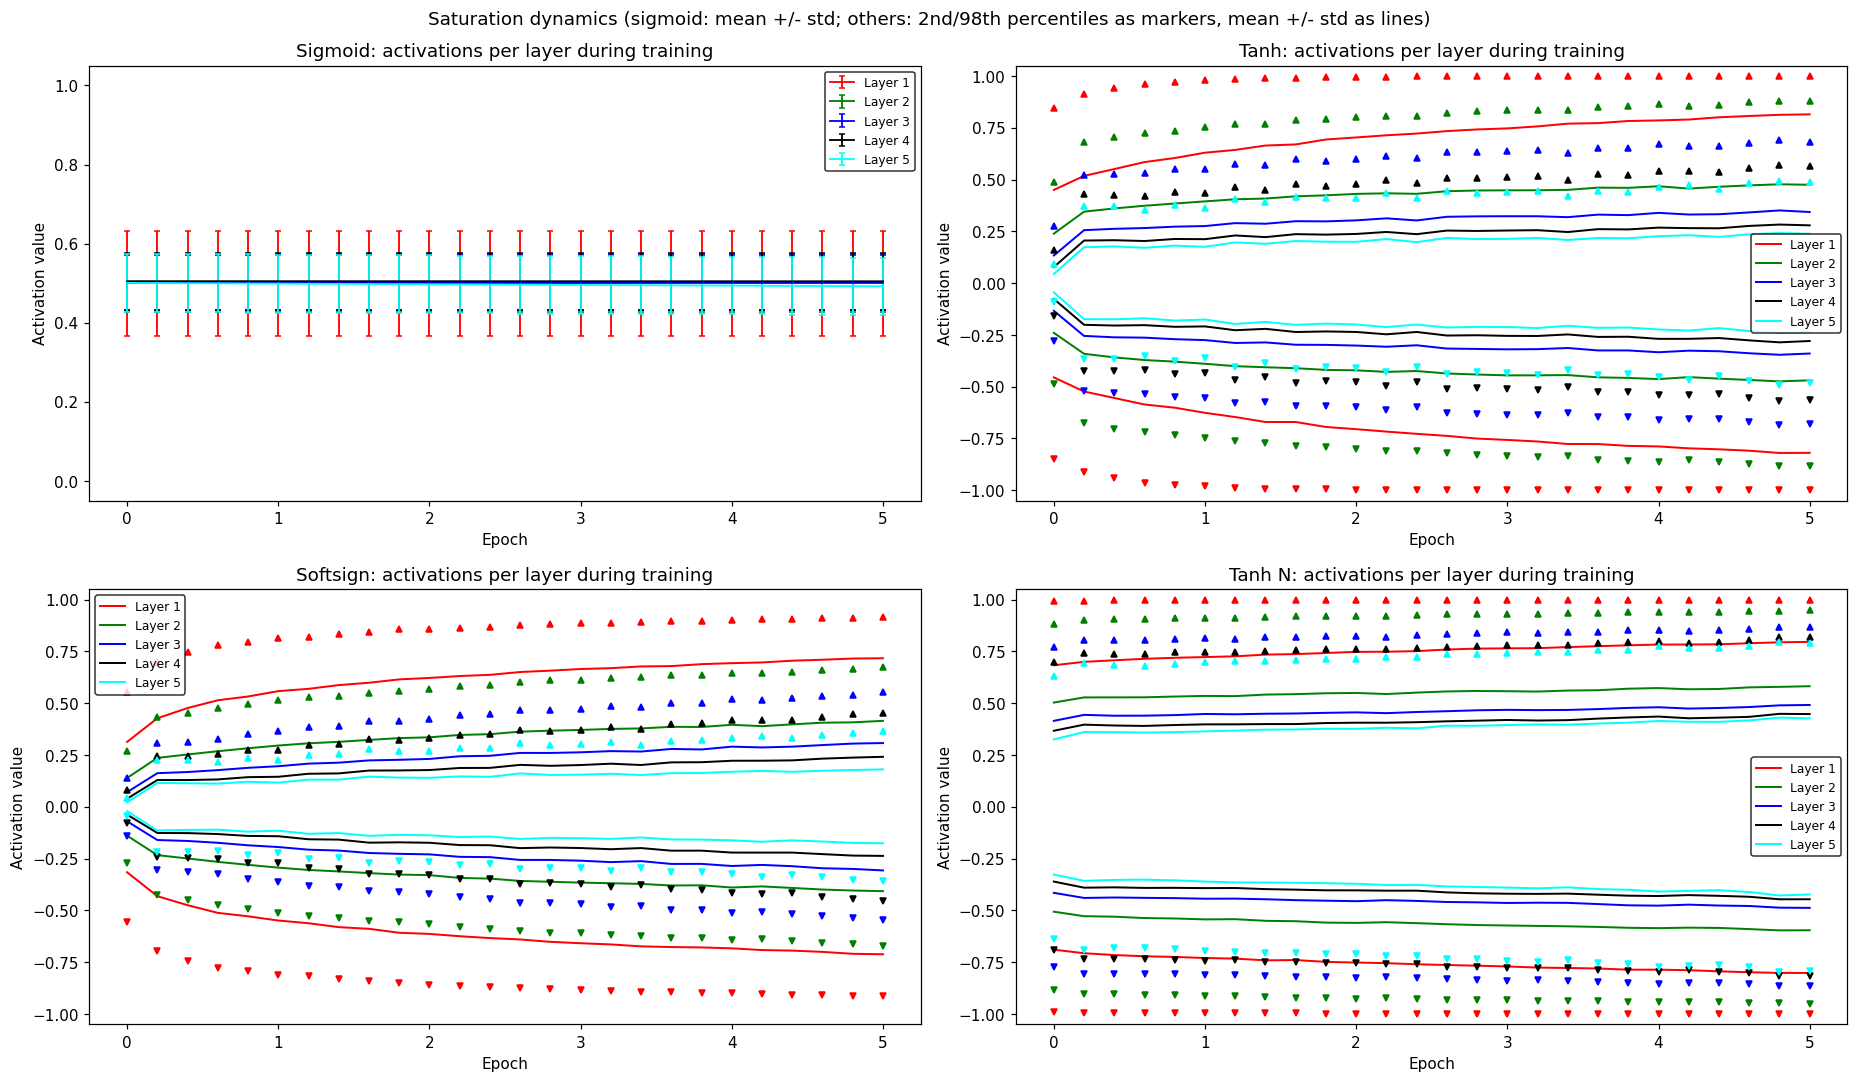

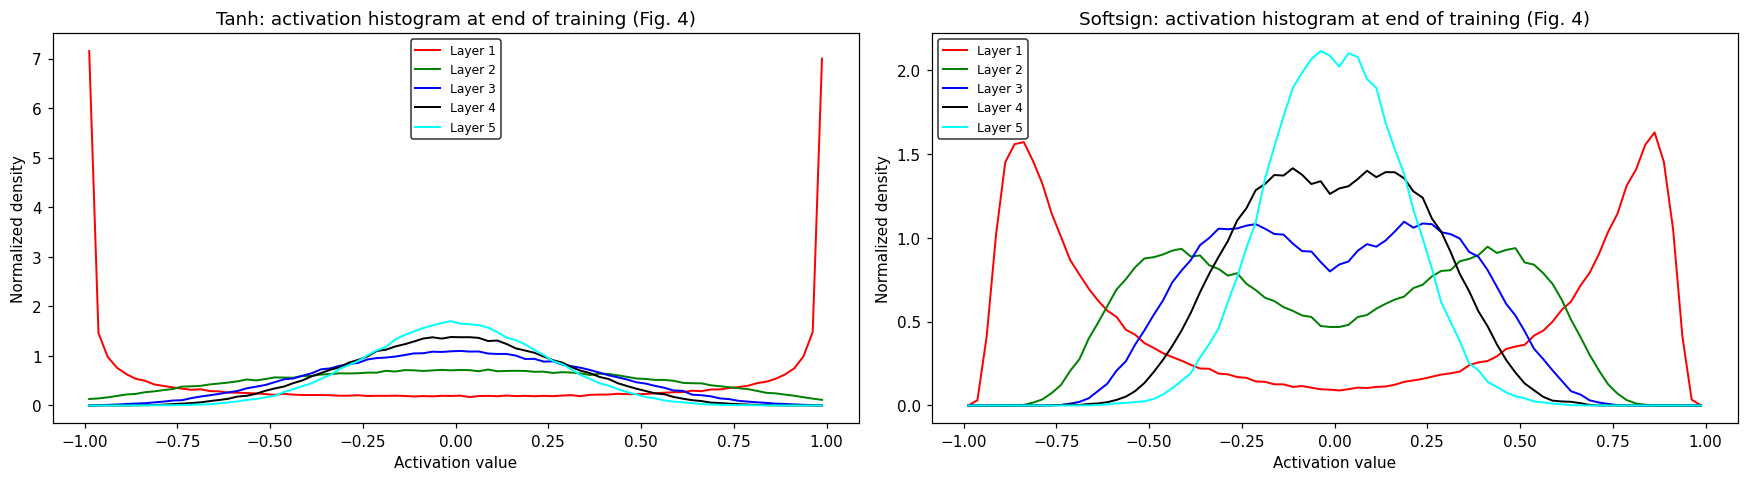

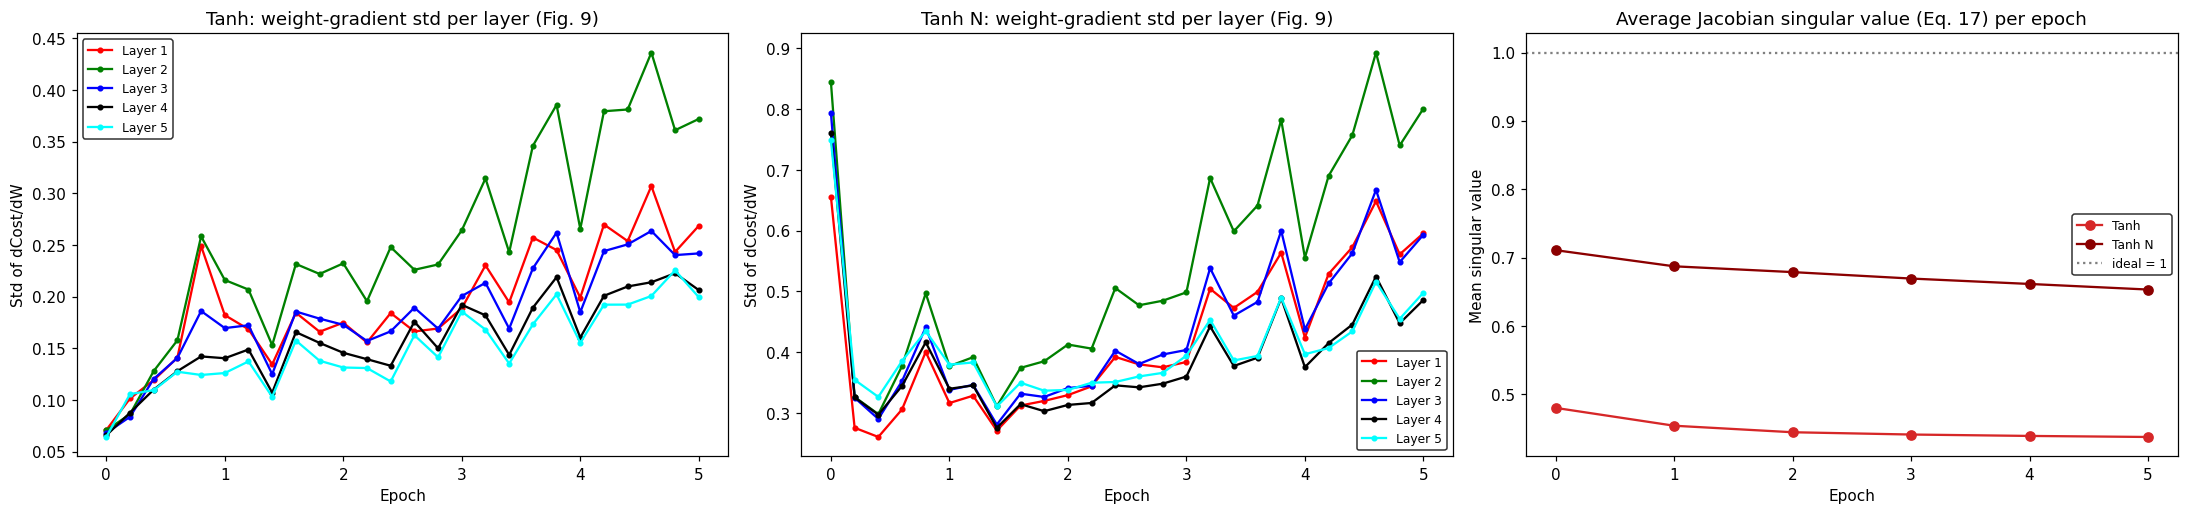

In [ ]:
# =============================================================================
# 9. STANDARD EDUCATIONAL PLOTS
# =============================================================================
# 9a. Learning curves for all configurations (Fig. 12, CIFAR-10 panel)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for name, _, _ in CONFIGS:
    h, col = results[name]["hist"], CFG_COLORS[name]
    e = np.arange(1, len(h["val_loss"]) + 1)
    axes[0].plot(e, h["val_loss"], marker="o", color=col, label=f"{name} (val)")
    axes[0].plot(e, h["train_loss"], ls="--", color=col, alpha=0.55)
    axes[1].plot(e, h["val_err"], marker="o", color=col, label=f"{name} (val)")
    axes[1].plot(e, h["train_err"], ls="--", color=col, alpha=0.55)
axes[0].set_title("NLL -log P(y|x): val (solid) / train (dashed)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("NLL"); axes[0].legend(fontsize=8)
axes[1].set_title("Error (%): val (solid) / train (dashed)  (cf. Fig. 12)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Error (%)"); axes[1].legend(fontsize=8)
for ax in axes: style_ax(ax)
fig.tight_layout(); show_fig(fig)

# 9b. Activation dynamics during training (Fig. 2 sigmoid, Fig. 3 tanh/softsign, Fig. 10 tanh N)
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
for ax, name in zip(axes.ravel(), ["Sigmoid", "Tanh", "Softsign", "Tanh N"]):
    h = results[name]["hist"]
    x = np.array(h["ckpt_x"])
    mean = np.array([c["mean"] for c in h["act"]]); std = np.array([c["std"] for c in h["act"]])
    p02 = np.array([c["p02"] for c in h["act"]]);   p98 = np.array([c["p98"] for c in h["act"]])
    for li in range(N_HIDDEN_LAYERS):
        col = LAYER_COLORS[li]
        if name == "Sigmoid":       # Fig. 2: mean with std bars
            ax.errorbar(x, mean[:, li], yerr=std[:, li], color=col, capsize=2, lw=1.2, label=f"Layer {li+1}")
        else:                       # Figs. 3/10: 98th percentiles (markers) + std (lines)
            ax.plot(x, p98[:, li], ls="none", marker="^", ms=4, color=col)
            ax.plot(x, p02[:, li], ls="none", marker="v", ms=4, color=col)
            ax.plot(x, mean[:, li] + std[:, li], color=col, lw=1.3, label=f"Layer {li+1}")
            ax.plot(x, mean[:, li] - std[:, li], color=col, lw=1.3)
    ax.set_ylim(-0.05, 1.05) if name == "Sigmoid" else ax.set_ylim(-1.05, 1.05)
    ax.set_title(f"{name}: activations per layer during training")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Activation value"); ax.legend(fontsize=8)
    style_ax(ax)
fig.suptitle("Saturation dynamics (sigmoid: mean +/- std; others: 2nd/98th percentiles as markers, "
             "mean +/- std as lines)", color="black", fontsize=12)
fig.tight_layout(); show_fig(fig)

# 9c. End-of-training activation histograms: tanh vs softsign (Fig. 4)
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
bins = np.linspace(-1, 1, 81)
for ax, name in zip(axes, ["Tanh", "Softsign"]):
    for li, vals in enumerate(results[name]["final_acts"]):
        density_line(ax, vals, bins, f"Layer {li+1}", LAYER_COLORS[li])
    ax.set_title(f"{name}: activation histogram at end of training (Fig. 4)")
    ax.set_xlabel("Activation value"); ax.set_ylabel("Normalized density"); ax.legend(fontsize=8)
    style_ax(ax)
fig.tight_layout(); show_fig(fig)

# 9d. Weight-gradient std during training (Fig. 9) + Jacobian singular values over epochs
fig, axes = plt.subplots(1, 3, figsize=(20, 4.8))
for ax, name in zip(axes[:2], ["Tanh", "Tanh N"]):
    h = results[name]["hist"]; x = np.array(h["ckpt_x"]); ws = np.array(h["wgrad_std"])
    for li in range(N_HIDDEN_LAYERS):
        ax.plot(x, ws[:, li], color=LAYER_COLORS[li], marker=".", label=f"Layer {li+1}")
    ax.set_title(f"{name}: weight-gradient std per layer (Fig. 9)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Std of dCost/dW"); ax.legend(fontsize=8)
    style_ax(ax)
for name in ["Tanh", "Tanh N"]:
    h = results[name]["hist"]
    axes[2].plot(h["jac_x"], np.array(h["jac"]).mean(axis=1), marker="o", color=CFG_COLORS[name], label=name)
axes[2].axhline(1.0, color="gray", ls=":", label="ideal = 1")
axes[2].set_title("Average Jacobian singular value (Eq. 17) per epoch")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Mean singular value"); axes[2].legend(fontsize=8)
style_ax(axes[2])
fig.tight_layout(); show_fig(fig)



=== QUALITATIVE PREDICTIONS (Tanh N) ===
Test image   0 | true: automobile  | pred: cat         | conf 0.27 | WRONG
Test image   1 | true: truck       | pred: truck       | conf 0.62 | correct
Test image   2 | true: truck       | pred: truck       | conf 0.44 | correct
Test image   3 | true: bird        | pred: frog        | conf 0.62 | WRONG
Test image   4 | true: dog         | pred: cat         | conf 0.38 | WRONG
Test image   5 | true: frog        | pred: frog        | conf 0.81 | correct
Test image   6 | true: automobile  | pred: horse       | conf 0.58 | WRONG
Test image   7 | true: horse       | pred: horse       | conf 0.72 | correct
Test image   8 | true: truck       | pred: horse       | conf 0.82 | WRONG
Test image   9 | true: bird        | pred: bird        | conf 0.46 | correct
Test image  10 | true: truck       | pred: truck       | conf 0.35 | correct
Test image  11 | true: airplane    | pred: truck       | conf 0.50 | WRONG


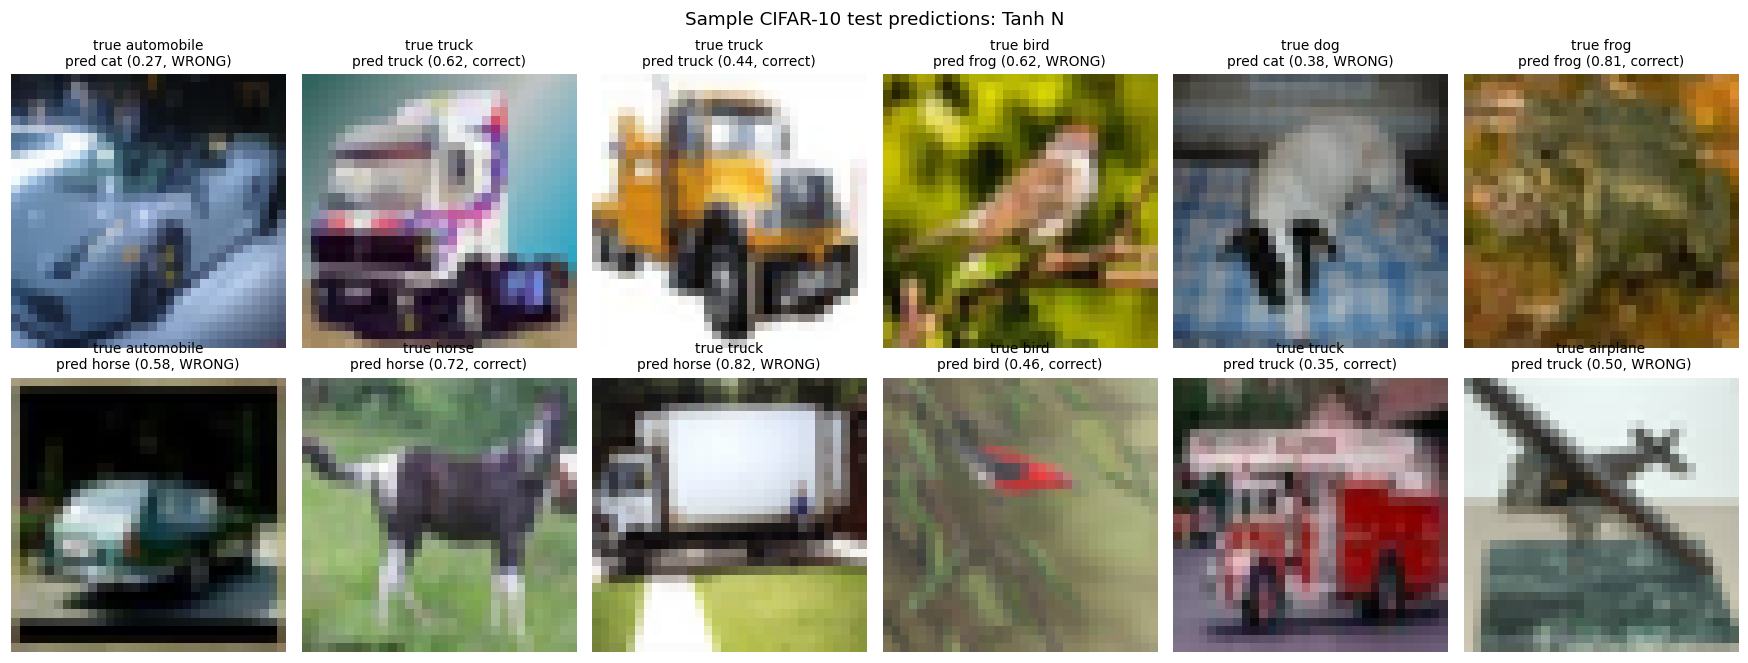

In [ ]:
# =============================================================================
# 10. PREDICTION PIPELINE (argmax of softmax, the paper's classifier)
# =============================================================================
def predict(model, X_np):
    """Return predicted class ids and confidences for standardized 3072-vectors."""
    with torch.no_grad():
        probs = torch.softmax(model(torch.from_numpy(X_np).to(DEVICE)), dim=1)
        conf, pred = probs.max(dim=1)
    return pred.cpu().numpy(), conf.cpu().numpy()

primary_model = results[PRIMARY]["model"]
sample_idx = np.arange(12)
s_pred, s_conf = predict(primary_model, X_test[sample_idx])
print(f"\n=== QUALITATIVE PREDICTIONS ({PRIMARY}) ===")
for k, i in enumerate(sample_idx):
    t, p = y_test[i], s_pred[k]
    print(f"Test image {i:3d} | true: {CLASS_NAMES[t]:<11} | pred: {CLASS_NAMES[p]:<11} | "
          f"conf {s_conf[k]:.2f} | {'correct' if t == p else 'WRONG'}")

fig, axes = plt.subplots(2, 6, figsize=(16, 6.2))
for k, ax in enumerate(axes.ravel()):
    i = sample_idx[k]
    ax.imshow(img_test[i])
    tag = "correct" if y_test[i] == s_pred[k] else "WRONG"
    ax.set_title(f"true {CLASS_NAMES[y_test[i]]}\npred {CLASS_NAMES[s_pred[k]]} "
                 f"({s_conf[k]:.2f}, {tag})", color="black", fontsize=9)
    ax.axis("off")
fig.suptitle(f"Sample CIFAR-10 test predictions: {PRIMARY}", color="black")
fig.tight_layout(); show_fig(fig)

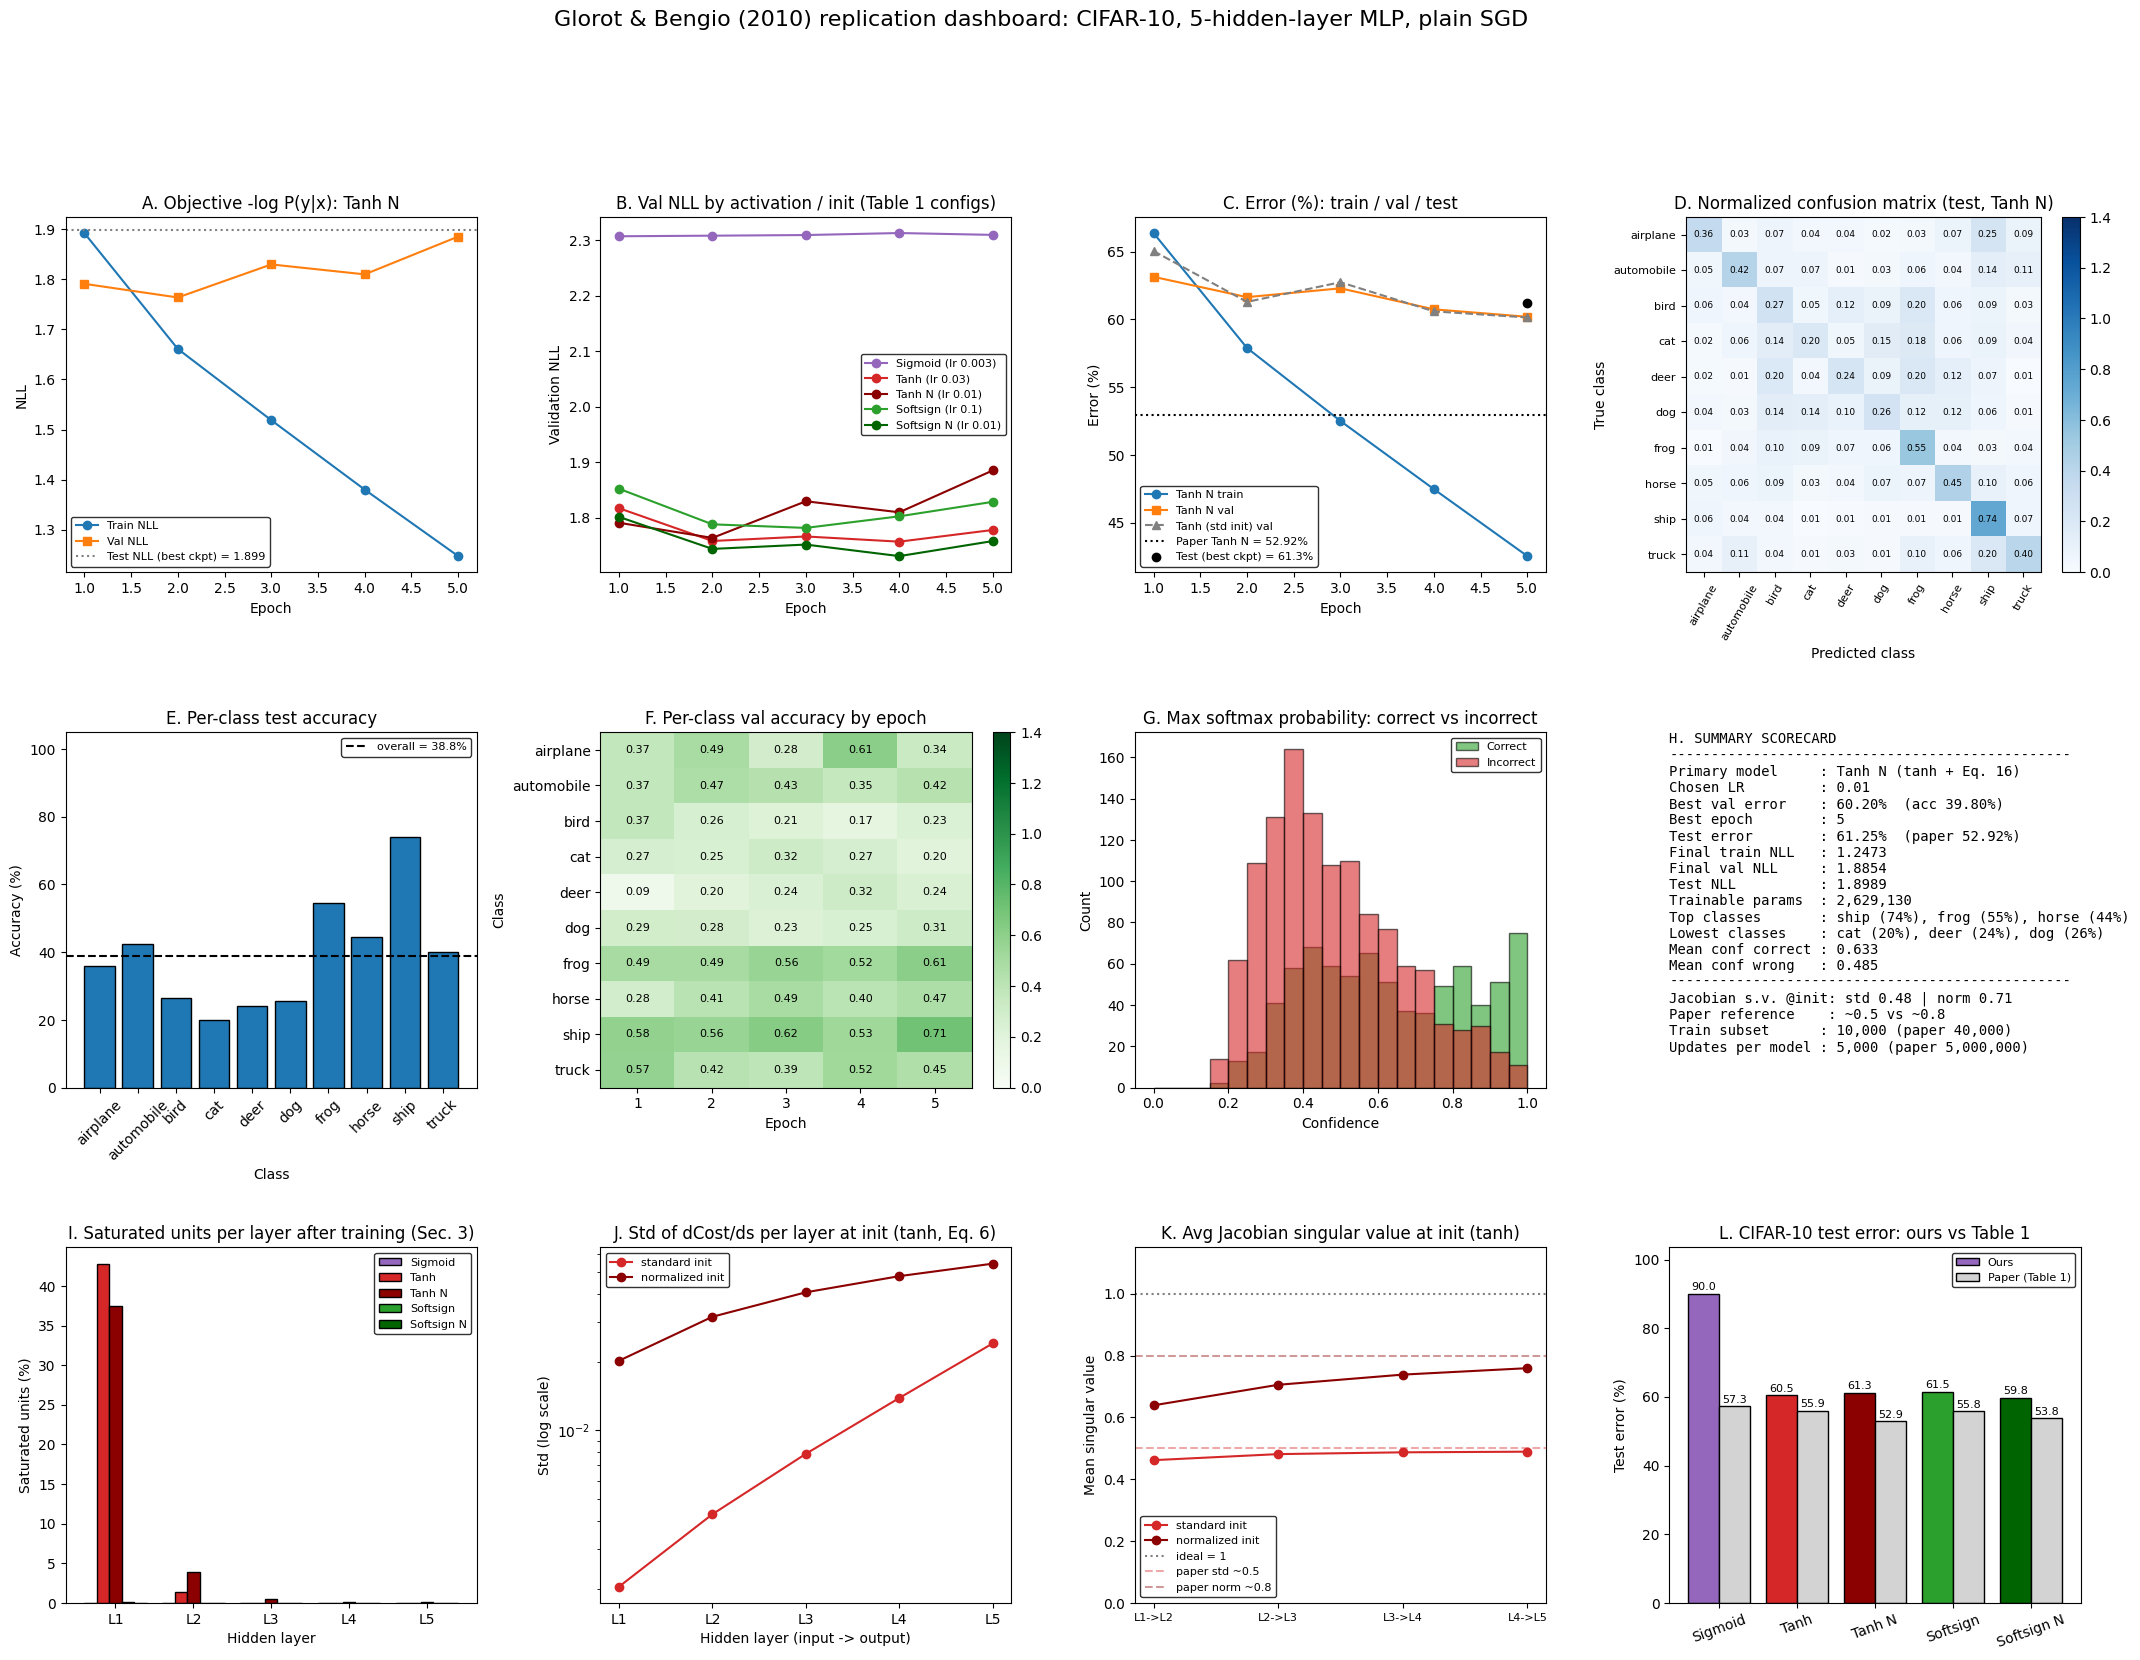

In [ ]:

# =============================================================================
# 11. SUMMARY DASHBOARD (3-row GridSpec, panels A-L)
#   A-H follow the requested template, adapted to this paper:
#     B: the paper has ONE objective (NLL); rather than inventing auxiliary
#        losses, B compares that objective across the 5 Table 1 configurations.
#     D/E/F: "class" = the 10 CIFAR-10 object classes.
#   I-L are paper-specific diagnostics (Secs. 3-4, Table 1).
# =============================================================================
plt.rcParams.update(WHITE_RC)

P = results[PRIMARY]
hP, tP = P["hist"], P["test"]
epP = np.arange(1, len(hP["val_loss"]) + 1)
cm = confusion_matrix_norm(tP["preds"], tP["labels"])
pc_test = per_class_accuracy(tP["preds"], tP["labels"])
pc_epoch = np.array(hP["val_per_class"])                      # (epochs, 10)
correct_mask = tP["preds"] == tP["labels"]
n_params = sum(p.numel() for p in P["model"].parameters() if p.requires_grad)
best_epoch = int(np.argmin(hP["val_err"])) + 1
best_val_err = float(np.min(hP["val_err"]))
order = np.argsort(-pc_test)
top3 = ", ".join(f"{CLASS_NAMES[c]} ({100*pc_test[c]:.0f}%)" for c in order[:3])
low3 = ", ".join(f"{CLASS_NAMES[c]} ({100*pc_test[c]:.0f}%)" for c in order[-3:][::-1])
conf_c = tP["conf"][correct_mask].mean() if correct_mask.any() else float("nan")
conf_i = tP["conf"][~correct_mask].mean() if (~correct_mask).any() else float("nan")

fig = plt.figure(figsize=(26, 18), facecolor="white")
gs = GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.30)

# A: train / val loss of the primary model
ax = fig.add_subplot(gs[0, 0])
ax.plot(epP, hP["train_loss"], marker="o", color="tab:blue", label="Train NLL")
ax.plot(epP, hP["val_loss"], marker="s", color="tab:orange", label="Val NLL")
ax.axhline(tP["loss"], color="gray", ls=":", label=f"Test NLL (best ckpt) = {tP['loss']:.3f}")
ax.set_title(f"A. Objective -log P(y|x): {PRIMARY}")
ax.set_xlabel("Epoch"); ax.set_ylabel("NLL"); ax.legend(fontsize=8); style_ax(ax)

# B: the single objective across the paper's configurations
ax = fig.add_subplot(gs[0, 1])
for name, _, _ in CONFIGS:
    h = results[name]["hist"]
    ax.plot(np.arange(1, len(h["val_loss"]) + 1), h["val_loss"], marker="o",
            color=CFG_COLORS[name], label=f"{name} (lr {results[name]['lr']})")
ax.set_title("B. Val NLL by activation / init (Table 1 configs)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation NLL"); ax.legend(fontsize=8); style_ax(ax)

# C: error (%) curves, the paper's metric
ax = fig.add_subplot(gs[0, 2])
ax.plot(epP, hP["train_err"], marker="o", color="tab:blue", label=f"{PRIMARY} train")
ax.plot(epP, hP["val_err"], marker="s", color="tab:orange", label=f"{PRIMARY} val")
hT = results["Tanh"]["hist"]
ax.plot(np.arange(1, len(hT["val_err"]) + 1), hT["val_err"], ls="--", marker="^",
        color="gray", label="Tanh (std init) val")
ax.axhline(PAPER_CIFAR10_ERR[PRIMARY], color="black", ls=":", label=f"Paper {PRIMARY} = {PAPER_CIFAR10_ERR[PRIMARY]}%")
ax.scatter([best_epoch], [tP["error"]], color="black", zorder=5, label=f"Test (best ckpt) = {tP['error']:.1f}%")
ax.set_title("C. Error (%): train / val / test")
ax.set_xlabel("Epoch"); ax.set_ylabel("Error (%)"); ax.legend(fontsize=8); style_ax(ax)

# D: normalized confusion matrix over the 10 CIFAR-10 classes
ax = fig.add_subplot(gs[0, 3])
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1.4)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=6.5, color="black")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=60, fontsize=8)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
ax.set_title(f"D. Normalized confusion matrix (test, {PRIMARY})")
cb = fig.colorbar(im, ax=ax, fraction=0.046); cb.ax.tick_params(colors="black")
style_ax(ax)

# E: per-class test accuracy
ax = fig.add_subplot(gs[1, 0])
ax.bar(CLASS_NAMES, 100 * pc_test, color="tab:blue", edgecolor="black")
ax.axhline(100 * tP["acc"], color="black", ls="--", label=f"overall = {100*tP['acc']:.1f}%")
ax.set_ylim(0, 105); ax.tick_params(axis="x", rotation=45)
ax.set_title("E. Per-class test accuracy")
ax.set_xlabel("Class"); ax.set_ylabel("Accuracy (%)"); ax.legend(fontsize=8); style_ax(ax)

# F: epoch-wise per-class validation accuracy heatmap
ax = fig.add_subplot(gs[1, 1])
im = ax.imshow(pc_epoch.T, cmap="Greens", vmin=0, vmax=1.4, aspect="auto")
for i in range(NUM_CLASSES):
    for j in range(pc_epoch.shape[0]):
        ax.text(j, i, f"{pc_epoch[j, i]:.2f}", ha="center", va="center", fontsize=8, color="black")
ax.set_xticks(range(pc_epoch.shape[0])); ax.set_xticklabels([str(e) for e in epP])
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Epoch"); ax.set_ylabel("Class")
ax.set_title("F. Per-class val accuracy by epoch")
cb = fig.colorbar(im, ax=ax, fraction=0.046); cb.ax.tick_params(colors="black")
style_ax(ax)

# G: softmax confidence, correct vs incorrect
ax = fig.add_subplot(gs[1, 2])
cbins = np.linspace(0, 1, 21)
ax.hist(tP["conf"][correct_mask], bins=cbins, alpha=0.6, color="tab:green", edgecolor="black", label="Correct")
ax.hist(tP["conf"][~correct_mask], bins=cbins, alpha=0.6, color="tab:red", edgecolor="black", label="Incorrect")
ax.set_title("G. Max softmax probability: correct vs incorrect")
ax.set_xlabel("Confidence"); ax.set_ylabel("Count"); ax.legend(fontsize=8); style_ax(ax)

# H: text scorecard
ax = fig.add_subplot(gs[1, 3]); ax.axis("off")
lines = [
    "H. SUMMARY SCORECARD",
    "-" * 48,
    f"Primary model     : {PRIMARY} (tanh + Eq. 16)",
    f"Chosen LR         : {P['lr']}",
    f"Best val error    : {best_val_err:.2f}%  (acc {100-best_val_err:.2f}%)",
    f"Best epoch        : {best_epoch}",
    f"Test error        : {tP['error']:.2f}%  (paper {PAPER_CIFAR10_ERR[PRIMARY]}%)",
    f"Final train NLL   : {hP['train_loss'][-1]:.4f}",
    f"Final val NLL     : {hP['val_loss'][-1]:.4f}",
    f"Test NLL          : {tP['loss']:.4f}",
    f"Trainable params  : {n_params:,}",
    f"Top classes       : {top3}",
    f"Lowest classes    : {low3}",
    f"Mean conf correct : {conf_c:.3f}",
    f"Mean conf wrong   : {conf_i:.3f}",
    "-" * 48,
    f"Jacobian s.v. @init: std {init_study['standard']['jac'].mean():.2f}"
    f" | norm {init_study['normalized']['jac'].mean():.2f}",
    "Paper reference    : ~0.5 vs ~0.8",
    f"Train subset      : {len(y_train):,} (paper 40,000)",
    f"Updates per model : {EPOCHS * UPDATES_PER_EPOCH:,} (paper 5,000,000)",
]
ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left", family="monospace",
        fontsize=10, color="black", transform=ax.transAxes)

# I: saturated units per layer at end of training
ax = fig.add_subplot(gs[2, 0])
w, xl = 0.16, np.arange(1, N_HIDDEN_LAYERS + 1)
for k, (name, _, _) in enumerate(CONFIGS):
    ax.bar(xl + (k - 2) * w, 100 * results[name]["saturation"], width=w,
           color=CFG_COLORS[name], edgecolor="black", label=name)
ax.set_xticks(xl); ax.set_xticklabels([f"L{i}" for i in xl])
ax.set_title("I. Saturated units per layer after training (Sec. 3)")
ax.set_xlabel("Hidden layer"); ax.set_ylabel("Saturated units (%)"); ax.legend(fontsize=8); style_ax(ax)

# J: back-propagated gradient std per layer at init (Fig. 7 summary, Eq. 6)
ax = fig.add_subplot(gs[2, 1])
for scheme, col in zip(SCHEMES, ["tab:red", "darkred"]):
    ax.plot(xl, init_study[scheme]["probe"]["back_std"], marker="o", color=col, label=f"{scheme} init")
ax.set_yscale("log")
ax.set_xticks(xl); ax.set_xticklabels([f"L{i}" for i in xl])
ax.set_title("J. Std of dCost/ds per layer at init (tanh, Eq. 6)")
ax.set_xlabel("Hidden layer (input -> output)"); ax.set_ylabel("Std (log scale)")
ax.legend(fontsize=8); style_ax(ax)

# K: Jacobian mean singular value per layer transition at init (Eq. 17)
ax = fig.add_subplot(gs[2, 2])
xj = np.arange(1, N_HIDDEN_LAYERS)
for scheme, col in zip(SCHEMES, ["tab:red", "darkred"]):
    ax.plot(xj, init_study[scheme]["jac"], marker="o", color=col, label=f"{scheme} init")
ax.axhline(1.0, color="gray", ls=":", label="ideal = 1")
ax.axhline(0.5, color="tab:red", ls="--", alpha=0.4, label="paper std ~0.5")
ax.axhline(0.8, color="darkred", ls="--", alpha=0.4, label="paper norm ~0.8")
ax.set_xticks(xj); ax.set_xticklabels([f"L{i}->L{i+1}" for i in xj], fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_title("K. Avg Jacobian singular value at init (tanh)")
ax.set_ylabel("Mean singular value"); ax.legend(fontsize=8); style_ax(ax)

# L: Table 1 analogue, ours vs paper
ax = fig.add_subplot(gs[2, 3])
names = [c[0] for c in CONFIGS]
xs = np.arange(len(names))
ours = [results[n]["test"]["error"] for n in names]
paper = [PAPER_CIFAR10_ERR[n] for n in names]
b1 = ax.bar(xs - 0.2, ours, width=0.4, color=[CFG_COLORS[n] for n in names], edgecolor="black", label="Ours")
b2 = ax.bar(xs + 0.2, paper, width=0.4, color="lightgray", edgecolor="black", label="Paper (Table 1)")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5, f"{b.get_height():.1f}",
                ha="center", va="bottom", color="black", fontsize=8)
ax.set_xticks(xs); ax.set_xticklabels(names, rotation=20)
ax.set_ylim(0, max(ours + paper) * 1.15)
ax.set_title("L. CIFAR-10 test error: ours vs Table 1")
ax.set_ylabel("Test error (%)"); ax.legend(fontsize=8); style_ax(ax)

fig.suptitle("Glorot & Bengio (2010) replication dashboard: CIFAR-10, 5-hidden-layer MLP, plain SGD",
             fontsize=16, color="black", y=0.995)

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=100, bbox_inches="tight", facecolor="white")
buf.seek(0)
plt.close(fig)
display(IPImage(data=buf.read()))